In [ ]:
# =====================================
# CONFIG — ISIC-2019 | 4-class | max 1,000 samples
# No caching, no class caps — uniform subsampling
# =====================================
from pathlib import Path

CONFIG = {
    # Paths
    'data_root': '/kaggle/input/datasets/andrewmvd/isic-2019',
    'image_dir': '/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input',
    'gt_csv': '/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_GroundTruth.csv',

    # Output Directories
    'output_dir': '/kaggle/working/outputs',
    'checkpoint_dir': '/kaggle/working/checkpoints',
    'results_dir': '/kaggle/working/results',
    'figures_dir': '/kaggle/working/figures',

    # Classes — 4 selected categories
    'class_names': ['MEL', 'NV', 'BCC', 'BKL'],
    'num_classes': 4,

    # Maximum total samples (balanced stratified subsample)
    'max_samples': 15000,  

    # Split Configuration
    'val_size': 0.10,  # 80/10/10 split

    # Training Hyperparameters
    'image_size': 224,
    'batch_size': 32,
    'num_epochs': 15,
    'retrain_epochs': 10,
    'lr': 1e-4,
    'retrain_lr': 5e-5,
    'weight_decay': 1e-4,
    'seed': 42,
    'num_workers': 4,
    'patience': 5,
    'retrain_patience': 3,
    'show_batch_progress': False,
    'prefetch_factor': 2,

    # No caching
    'use_cache': False,

    # Failure Analysis
    'pca_components': 32,
    'umap_neighbors': 15,
    'umap_min_dist': 0.1,
    'k_range': range(2, 7),
    'small_failure_umap_threshold': 300,
    'max_aug_source': 300,
    'ece_bins': 15,
    'aug_multiplier': 3,

    # Degradation Guard
    'guard_f1_max_drop': 0.000,
    'guard_acc_max_drop': 0.005,
    'guard_ece_max_rise': 0.010,
    'guard_weak_baseline_f1': 0.55,
    'guard_weak_f1_max_drop': 0.005,
    'guard_weak_acc_max_drop': 0.010,
    'guard_weak_ece_max_rise': 0.025,
}

MODELS = [
    'resnet50',
    'resnet101',
    # 'densenet121',
    # 'efficientnet_b3',
    # 'efficientnet_b5',
    # 'mobilenetv3_large_100',
    # 'vit_base_patch16_224',
    # 'swin_tiny_patch4_window7_224',
    # 'convnext_small',
    # 'maxvirt_tiny_tf_224',  # Typo: "virt" ❌
]

# Correct typo if exists
if 'maxvirt_tiny_tf_224' in MODELS:
    MODELS = ['maxvit_tiny_tf_224' if m == 'maxvirt_tiny_tf_224' else m for m in MODELS]

# Ensure output directories exist
for d in [CONFIG['output_dir'], CONFIG['checkpoint_dir'], CONFIG['results_dir'], CONFIG['figures_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("? CONFIG loaded - ISIC 2019 | 4-class | Max 1,000 samples | No cache")
print(f"  Max Samples: {CONFIG['max_samples']:,}")
print(f"  Training: {CONFIG['num_epochs']} epochs | lr={CONFIG['lr']} | patience={CONFIG['patience']}")
print(f"  DataLoader: workers={CONFIG['num_workers']} | persistent_workers=True")

? CONFIG loaded - ISIC 2019 | 4-class | Max 1,000 samples | No cache
  Max Samples: 13,000
  Training: 15 epochs | lr=0.0001 | patience=5
  DataLoader: workers=4 | persistent_workers=True


In [2]:
!pip install -q timm umap-learn torchmetrics

import os, random, warnings, gc, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, confusion_matrix, precision_recall_fscore_support
)
import umap
import torchmetrics

try:
    from scipy import ndimage
except Exception:
    ndimage = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def set_all_seeds(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducible Kaggle runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_all_seeds(CONFIG['seed'])

for key in ['output_dir', 'checkpoint_dir', 'results_dir', 'figures_dir']:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "GPU is required for this Kaggle experiment."
device = torch.device("cuda")
print(f"Using device: {device} | GPU: {torch.cuda.get_device_name(0)}")
print("✓ Section 1 complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

2026-06-18 07:40:02.689405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781768402.894050      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781768402.952499      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781768403.477281      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781768403.477324      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781768403.477327      23 computation_placer.cc:177] computation placer alr

Using device: cuda | GPU: Tesla T4
✓ Section 1 complete


In [3]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


In [4]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


Using ISIC root    : /kaggle/input/datasets/andrewmvd/isic-2019
Image folder       : /kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input
Ground truth       : /kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_GroundTruth.csv
Target max samples : 13,000
Loaded: 23,344 samples after class filtering
Resolving image paths...
Valid paths: 23,344
Subsampling from 23,344 → 13,000 (stratified)
✅ Downsampled to: 10,344
Final class distribution (after subsample):
label_name
MEL    2004
NV     5705
BCC    1472
BKL    1163
Name: count, dtype: int64

Splits -> Train: 8,275 | Val: 1,034 | Test: 1,035

Train distribution:
label_name
MEL    1603
NV     4564
BCC    1178
BKL     930
Name: count, dtype: int64

Val distribution:
label_name
MEL    200
NV     570
BCC    147
BKL    117
Name: count, dtype: int64

Test distribution:
label_name
MEL    201
NV     571
BCC    147
BKL    116
Name: count, dtype: int64

Splits saved to /kaggle/working and results_di

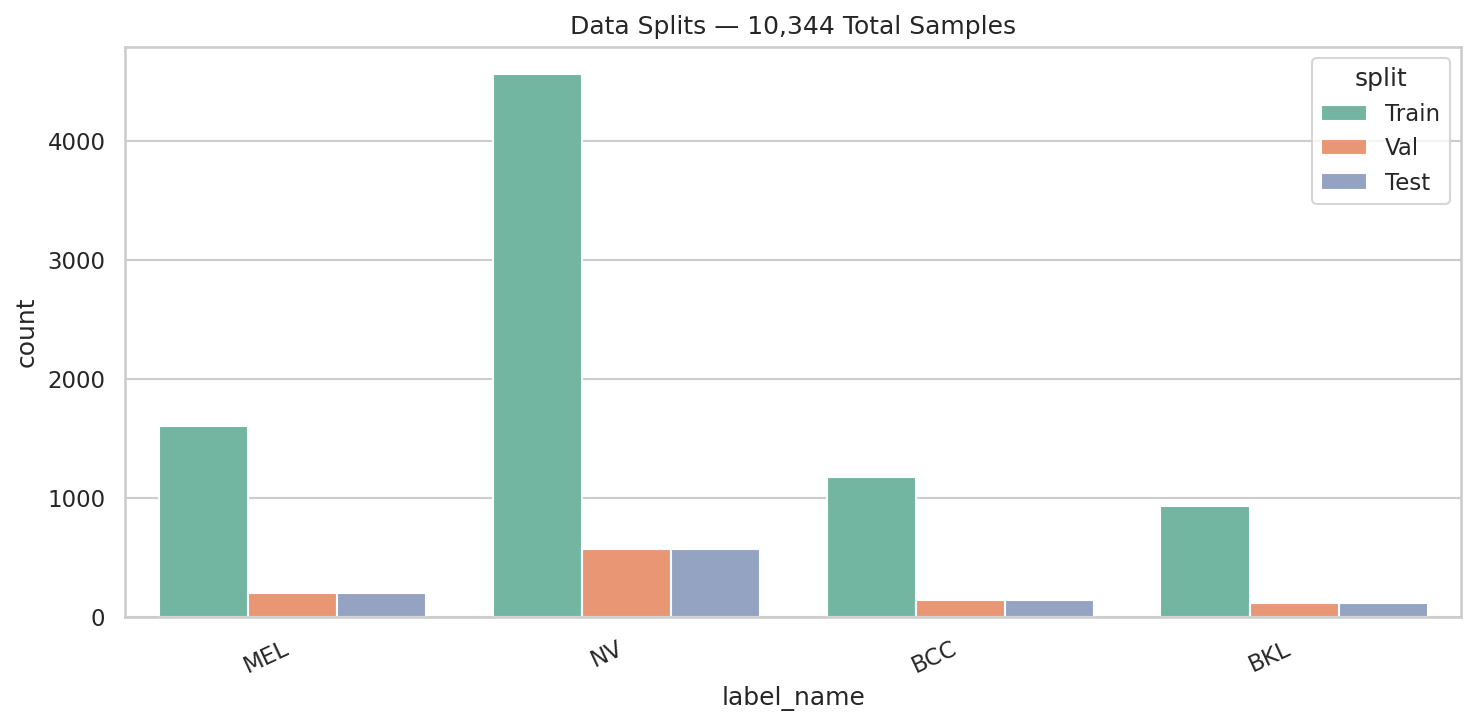

? Section 2 complete


In [5]:
# =====================================
# Section 2: Data Loading & Stratified Split
# Ensures total samples == max_samples (stratified subsample)
# =====================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

def get_isic_label(row: pd.Series, class_names):
    """Return the first selected one-hot ISIC class name for a row, or None."""
    for label_name in class_names:
        if float(row.get(label_name, 0.0)) == 1.0:
            return label_name
    return None

def find_isic_image_path(image_id, image_dir: Path):
    """Resolve an ISIC image id to full path using common extensions."""
    for ext in ['.jpg', '.jpeg', '.png', '.JPG']:
        path = image_dir / f'{image_id}{ext}'
        if path.exists():
            return str(path)
    return None

def preprocess_labels(config: dict):
    """Load, filter, path-resolve, subsample to max_samples, and split 80/10/10."""
    image_dir = Path(config['image_dir'])
    gt_csv = Path(config['gt_csv'])

    if not image_dir.exists():
        raise FileNotFoundError(f"Image directory not found: {image_dir}")
    if not gt_csv.exists():
        raise FileNotFoundError(f"CSV file not found: {gt_csv}")

    print(f"Using ISIC root    : {config['data_root']}")
    print(f"Image folder       : {image_dir}")
    print(f"Ground truth       : {gt_csv}")
    print(f"Target max samples : {config['max_samples']:,}")

    # Load and filter to 4 classes
    gt_df = pd.read_csv(gt_csv)
    gt_df['label_name'] = gt_df.apply(
        lambda row: get_isic_label(row, config['class_names']),
        axis=1
    )
    gt_df = gt_df[gt_df['label_name'].notna()].reset_index(drop=True)
    print(f"Loaded: {len(gt_df):,} samples after class filtering")

    # Resolve image paths
    print("Resolving image paths...")
    gt_df['image_path'] = gt_df['image'].apply(lambda image_id: find_isic_image_path(image_id, image_dir))
    gt_df = gt_df[gt_df['image_path'].notna()].reset_index(drop=True)
    print(f"Valid paths: {len(gt_df):,}")

    # 🔴 CRITICAL FIX: Enforce max_samples
    if config['max_samples'] and len(gt_df) > config['max_samples']:
        print(f"Subsampling from {len(gt_df):,} → {config['max_samples']:,} (stratified)")
        _, gt_df = train_test_split(
            gt_df,
            train_size=config['max_samples'],
            stratify=gt_df['label_name'],  # Keeps class distribution
            random_state=config['seed']
        )
        gt_df = gt_df.reset_index(drop=True)
        print(f"✅ Downsampled to: {len(gt_df):,}")

    # Encode labels
    label_to_idx = {name: idx for idx, name in enumerate(config['class_names'])}
    gt_df['label'] = gt_df['label_name'].map(label_to_idx).astype(int)
    gt_df['original_labels'] = gt_df['label_name']

    full_df = gt_df[['image', 'image_path', 'label', 'label_name', 'original_labels']].copy()

    # Print final distribution
    print(f"Final class distribution (after subsample):")
    print(full_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    # SPLIT: 80/10/10
    val_size_total = config.get('val_size', 0.10)
    test_size = 0.2  # Hold out 20% for val+test

    # First: 80% train / 20% (val+test)
    train_temp, testplus = train_test_split(
        full_df,
        test_size=test_size,
        random_state=config['seed'],
        stratify=full_df['label']
    )

    # Split remaining 20% into 50/50 → 10% val, 10% test
    val_df, test_df = train_test_split(
        testplus,
        test_size=0.5,
        random_state=config['seed'],
        stratify=testplus['label']
    )

    train_df = train_temp.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"\nSplits -> Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

    for split_name, split_data in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"\n{split_name} distribution:")
        print(split_data['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    # Save splits
    for fname, df_split in [
        ('train_split.csv', train_df),
        ('val_split.csv', val_df),
        ('test_split.csv', test_df)
    ]:
        df_split.to_csv(f"/kaggle/working/{fname}", index=False)
        df_split.to_csv(f"{config['results_dir']}/{fname}", index=False)
    print("\nSplits saved to /kaggle/working and results_dir")

    # Plot distribution
    dist = pd.concat([
        train_df.assign(split='Train'),
        val_df.assign(split='Val'),
        test_df.assign(split='Test')
    ])

    plt.figure(figsize=(10, 5), dpi=150)
    ax = sns.countplot(
        data=dist,
        x='label_name',
        hue='split',
        order=config['class_names'],
        palette='Set2'
    )
    plt.xticks(rotation=25, ha='right')
    plt.title(f"Data Splits — {len(full_df):,} Total Samples")
    plt.tight_layout()
    plt.savefig(f"{config['figures_dir']}/section2_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    return train_df, val_df, test_df

# =============================
# Run preprocessing
# =============================
train_df, val_df, test_df = preprocess_labels(CONFIG)
print("? Section 2 complete")

In [6]:
# =====================================
# Section 3: Dataset Definition & DataLoaders
# Aligned to unified pipeline (shared with Kvasir, BUSI, COVID)
# =====================================
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from torchvision.transforms import functional as F
from PIL import Image
import pandas as pd


# =====================================
# Dataset Class — Shared ISIC / Kvasir Pattern (Unified)
# =====================================
class ISICDataset(Dataset):
    """Unified skin/endoscopy dataset loader: loads RGB tensors from resolved image paths."""
    missing_warning_count = 0

    def __init__(self, df: pd.DataFrame, transform=None, image_dir=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            ISICDataset.missing_warning_count += 1
            if ISICDataset.missing_warning_count <= 10:
                print(f"Warning: missing image, using blank placeholder: {image_path}")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        except Exception as exc:
            ISICDataset.missing_warning_count += 1
            if ISICDataset.missing_warning_count <= 10:
                print(f"Warning: failed to load {image_path}: {exc}; using blank placeholder")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        
        if self.transform:
            image = self.transform(image)
        return image, int(row['label']), image_path


# =====================================
# Transforms — Shared Across All Datasets
# =====================================
def get_transforms(split: str, image_size: int):
    """Standardized transforms using ImageNet stats (shared across all datasets)."""
    mean = [0.485, 0.456, 0.406]  # ImageNet
    std  = [0.229, 0.224, 0.225]

    if split == 'train':
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    elif split == 'heavy':
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.2),
            T.RandomRotation(degrees=25),
            T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.05),
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    else:  # 'val', 'test', or default
        return T.Compose([
            T.Resize(image_size),
            T.CenterCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])


# =====================================
# Augmented Dataset (Failure Cluster Retraining)
# =====================================
class AugmentedISICDataset(ISICDataset):
    """Applies heavy augmentations if row['is_augmented'] is True."""
    def __init__(self, df, normal_transform, heavy_transform):
        super().__init__(df, normal_transform)
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        transform = self.heavy_transform if bool(row.get('is_augmented', False)) else self.normal_transform
        old_transform = self.transform
        self.transform = transform
        item = super().__getitem__(idx)
        self.transform = old_transform
        return item


# =====================================
# Class Weights & DataLoader Factory
# =====================================
def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Compute inverse-frequency class weights for loss balancing."""
    counts = df['label'].value_counts().reindex(range(num_classes)).fillna(1).astype(float).values
    total = counts.sum()
    weights = total / (num_classes * counts)  # Balanced weight formula
    return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    config: dict,
    val_df: pd.DataFrame = None
):
    """
    Build train/val/test DataLoaders with optional val_df or split internally.
    Uses WeightedRandomSampler for class balance during training.
    """
    # Use external val_df if provided, else split from train_df
    if val_df is None:
        train_split, val_split = train_test_split(
            train_df,
            test_size=config.get('val_size', 0.1),
            random_state=config['seed'],
            stratify=train_df['label']
        )
    else:
        train_split = train_df.copy()
        val_split = val_df.copy()

    # Transforms
    train_transform = get_transforms('train', config['image_size'])
    heavy_transform = get_transforms('heavy', config['image_size'])
    eval_transform = get_transforms('test', config['image_size'])

    # Datasets
    if 'is_augmented' in train_split.columns:
        train_ds = AugmentedISICDataset(train_split, train_transform, heavy_transform)
    else:
        train_ds = ISICDataset(train_split, train_transform, config['image_dir'])
    
    val_ds = ISICDataset(val_split, eval_transform, config['image_dir'])
    test_ds = ISICDataset(test_df, eval_transform, config['image_dir'])

    # Class and sample weights
    class_weights = compute_class_weights(train_split, config['num_classes'])
    
    if 'sample_weight' in train_split.columns:
        sample_weights = train_split['sample_weight'].astype(float).values
    else:
        label_weight_map = {i: class_weights[i].item() for i in range(config['num_classes'])}
        sample_weights = train_split['label'].map(label_weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    # DataLoader kwargs (aligned with modern PyTorch practices)
    loader_kwargs = {
        'batch_size': config['batch_size'],
        'num_workers': config['num_workers'],
        'pin_memory': True,
        'persistent_workers': True if config['num_workers'] > 0 else False,
    }
    # Add prefetch_factor if supported
    if config['num_workers'] > 0:
        loader_kwargs['prefetch_factor'] = config.get('prefetch_factor', 2)

    # Build final loaders
    train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader, class_weights


# =============================
# Run Dataloader Creation
# =============================
train_loader, val_loader, test_loader, class_weights = get_dataloaders(
    train_df, test_df, CONFIG, val_df=val_df
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"Class weights: {class_weights.tolist()}")
print("? Section 3 complete")

Train batches: 259 | Val batches: 33 | Test batches: 33
Class weights: [1.2905489206314087, 0.4532756209373474, 1.7561545372009277, 2.2244622707366943]
? Section 3 complete


In [7]:
# =====================================
# Section 4: Model Definition & Embedding Hook
# Fully aligned with final pipeline (shared across Kvasir, ISIC, BUSI, COVID)
# =====================================
import torch
import torch.nn as nn
import torchvision.models as models
import timm


# =====================================
# get_model — Unified model loader with head replacement
# =====================================
def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """
    Load a model from torchvision or timm, replace final head, and move to device.
    Returns: model (on device) with custom classifier head.
    """
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'mobilenetv3_large_100':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        # Fall back to timm for all other models (EfficientNet, ViT, Swin, ConvNeXt, etc.)
        model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )
    
    # Move to device (assumes `device` is defined globally — e.g., torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    model = model.to(device)
    
    # Print model size summary
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {params/1e6:.2f}M params ({trainable/1e6:.2f}M trainable)")
    
    return model


# =====================================
# get_embedding_hook — Extract penultimate-layer embeddings
# Supports CNNs and Transformers
# =====================================
def get_embedding_hook(model: nn.Module, model_name: str):
    """
    Registers a forward hook on the best penultimate layer to capture embeddings.
    Stores output in a CPU tensor via `embedding_store`.
    Returns: handle (to remove later), embedding_store (dict with 'embedding' key).
    """
    embedding_store = {}

    def hook_fn(module, inputs, output):
        out = output
        # Handle models that return tuples/lists (e.g., ViT, Swin)
        if isinstance(out, (tuple, list)):
            out = out[0]

        # For 4D outputs: CNN-style (B, C, H, W) → global avg pool to (B, C)
        if out.ndim == 4:
            out = torch.nn.functional.adaptive_avg_pool2d(out, 1).flatten(1)
        # For 3D outputs: Transformer (B, N, D) → use [CLS] token or average
        elif out.ndim == 3:
            out = out[:, 0] if out.shape[1] > 1 else out.mean(dim=1)
        # Flatten anything else (rare)
        else:
            out = out.flatten(1)

        # Store detached CPU tensor
        embedding_store['embedding'] = out.detach().cpu()

    # Determine target layer by architecture family
    target = None

    if model_name.startswith('resnet'):
        target = model.avgpool
    elif model_name.startswith('densenet'):
        target = model.features
    elif model_name.startswith('efficientnet') and hasattr(model, 'global_pool'):
        target = model.global_pool
    elif model_name.startswith('mobilenetv3') and hasattr(model, 'avgpool'):
        target = model.avgpool
    elif model_name.startswith('vit') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('swin') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('convnext'):
        # ConvNeXt: either stem norm or head global_pool
        target = getattr(model, 'norm_pre', None) or getattr(getattr(model, 'head', None), 'global_pool', None)
    elif model_name.startswith('maxvit') and hasattr(model, 'norm'):
        target = model.norm

    # Validation
    if target is None:
        if hasattr(model, 'forward_features'):
            raise ValueError(
                f"Architecture '{model_name}' requires manual hook target — please add support."
            )
        else:
            raise ValueError(
                f"Model '{model_name}' not recognized. Use torchvision or timm model names."
            )

    # Register forward hook
    handle = target.register_forward_hook(hook_fn)
    return handle, embedding_store


# =====================================
# get_model_family — Group models for retraining strategies
# =====================================
def get_model_family(model_name: str) -> str:
    """
    Map model name to family for strategy routing in retraining (Section 10+).
    Used to apply architecture-specific augmentation or LR schedules.
    """
    if model_name.startswith('efficientnet'):
        return 'efficient'
    elif model_name.startswith(('vit', 'swin', 'convnext', 'maxvit')):
        return 'transformer'
    else:
        return 'cnn'  # resnet, densenet, mobilenet


print("✓ Section 4 complete")

✓ Section 4 complete


In [8]:
# =====================================
# Section 5: Training & Evaluation
# Fully aligned with final pipeline (shared across Kvasir, BUSI, COVID)
# =====================================
from torch.cuda.amp import autocast, GradScaler
from torchmetrics import classification as torchmetrics_classification
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from pathlib import Path

# =====================================
# train_one_epoch: Mixed Precision
# =====================================
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """
    Train one epoch using CUDA mixed precision.
    Returns average loss and accuracy.
    """
    model.train()
    total_loss = correct = total = 0
    progress_desc = 'train' if CONFIG.get('show_batch_progress', False) else None

    for images, labels, _ in tqdm(
        loader,
        desc=progress_desc,
        leave=False,
        disable=not CONFIG.get('show_batch_progress', False)
    ):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


# =====================================
# evaluate: Full Metrics + Outputs
# =====================================
def evaluate(model, loader, criterion, device, num_classes, class_names):
    """
    Evaluate model and return comprehensive metrics and outputs.
    Includes: loss, acc, F1, AUC, ECE, and full arrays for analysis.
    """
    model.eval()
    f1_metric = torchmetrics_classification.F1Score(
        task='multiclass',
        num_classes=num_classes,
        average='macro'
    ).to(device)

    auc_metric = torchmetrics_classification.AUROC(
        task='multiclass',
        num_classes=num_classes,
        average='macro'
    ).to(device)

    total_loss = correct = total = 0
    probs_all, labels_all, preds_all, paths_all = [], [], [], []

    progress_desc = 'eval' if CONFIG.get('show_batch_progress', False) else None
    with torch.no_grad():
        for images, labels, paths in tqdm(
            loader,
            desc=progress_desc,
            leave=False,
            disable=not CONFIG.get('show_batch_progress', False)
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)

            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            f1_metric.update(preds, labels)
            auc_metric.update(probs, labels)

            probs_all.append(probs.cpu().numpy())
            labels_all.append(labels.cpu().numpy())
            preds_all.append(preds.cpu().numpy())
            paths_all.extend(list(paths))

    # Concatenate
    probs_array = np.concatenate(probs_all) if probs_all else np.empty((0, num_classes))
    labels_array = np.concatenate(labels_all) if labels_all else np.array([])
    preds_array = np.concatenate(preds_all) if preds_all else np.array([])

    try:
        auc = float(auc_metric.compute().cpu())
    except Exception as e:
        print(f"⚠️ AUROC computation failed: {e}")
        auc = np.nan

    ece = compute_ece(probs_array, labels_array, CONFIG['ece_bins']) if len(labels_array) else np.nan

    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
        'f1': float(f1_metric.compute().cpu()),
        'auc': auc,
        'ece': ece,
        'probs': probs_array,
        'labels': labels_array,
        'preds': preds_array,
        'paths': paths_all,
    }


# =====================================
# compute_ece: Expected Calibration Error
# =====================================
def compute_ece(probs_array, labels_array, n_bins=15):
    """
    Compute Expected Calibration Error over confidence bins.
    """
    probs_array = np.asarray(probs_array)
    labels_array = np.asarray(labels_array)

    if len(labels_array) == 0:
        return np.nan

    confidences = probs_array.max(axis=1)
    predictions = probs_array.argmax(axis=1)
    accuracies = (predictions == labels_array).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += mask.mean() * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)


# =====================================
# plot_confusion_matrix: Normalized Plot
# =====================================
def plot_confusion_matrix(cm, class_names, model_name, save=True, suffix='baseline'):
    """
    Plot normalized confusion matrix.
    Add title and dataset-identifying filename.
    """
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=(row_sums != 0)
    )

    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix ({suffix.title()})")
    plt.tight_layout()

    if save:
        save_path = f"{CONFIG['figures_dir']}/confusion_{suffix}_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✅ Confusion matrix saved: {save_path}")
    plt.show()


# =====================================
# train_model: Full Training Loop
# =====================================
def train_model(model_name, train_loader, val_loader, class_weights, config):
    """
    Train baseline model with early stopping on validation macro F1.
    Returns:
      - model: best weights loaded
      - history: dict of training curves
      - best_val_metrics: dict of final metrics (safe keys)
    """
    print(f"\n{'='*60}")
    print(f" TRAINING: {model_name} (ISIC 2019)")
    print(f"{'='*60}")

    model = get_model(model_name, config['num_classes'], pretrained=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = GradScaler()

    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0

    # Safe default in case no epochs run
    best_val_metrics = {
        'val_loss': float('nan'),
        'val_acc': float('nan'),
        'val_f1': float('nan'),
        'val_auc': float('nan'),
        'val_ece': float('nan'),
    }

    # Checkpoint path — dataset-identifying
    ckpt_path = Path(config['checkpoint_dir']) / f"best_isic_{model_name}.pth"
    Path(config['checkpoint_dir']).mkdir(parents=True, exist_ok=True)

    for epoch in range(1, config['num_epochs'] + 1):
        print(f"Epoch {epoch}/{config['num_epochs']} | {model_name}")

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
        scheduler.step()

        # Log history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_ece'].append(val_metrics['ece'])

        print(f"  TRAIN loss: {train_loss:.4f} | acc: {train_acc:.3f}")
        print(f"  VAL   loss: {val_metrics['loss']:.4f} | acc: {val_metrics['accuracy']:.3f} | "
              f"F1: {val_metrics['f1']:.4f} | AUC: {val_metrics['auc']:.4f} | ECE: {val_metrics['ece']:.4f}")

        # Save best model by macro-F1
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_val_metrics.update({
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_f1': val_metrics['f1'],
                'val_auc': val_metrics['auc'],
                'val_ece': val_metrics['ece'],
            })
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ✅ Saved best model (F1={best_f1:.4f}): {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  ⚠️ Early stopping at epoch {epoch}. Best val F1={best_f1:.4f}")
                break

    # Load best weights
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    print(f"✅ Training complete: best weights loaded from {ckpt_path}")

    return model, dict(history), best_val_metrics


print("✓ Section 5 complete")

✓ Section 5 complete



✓ Starting baseline evaluation: 2 models | ISIC 2019


Evaluating models:   0%|          | 0/2 [00:00<?, ?it/s]


  TRAINING: resnet50

 TRAINING: resnet50 (ISIC 2019)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  9%|▉         | 8.88M/97.8M [00:00<00:01, 93.0MB/s]
 33%|███▎      | 32.1M/97.8M [00:00<00:00, 181MB/s] 
 56%|█████▋    | 55.1M/97.8M [00:00<00:00, 208MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


resnet50: 23.52M params (23.52M trainable)
Epoch 1/15 | resnet50
  TRAIN loss: 0.7730 | acc: 0.604
  VAL   loss: 0.8580 | acc: 0.550 | F1: 0.5578 | AUC: 0.8764 | ECE: 0.1460
  ✅ Saved best model (F1=0.5578): /kaggle/working/checkpoints/best_isic_resnet50.pth
Epoch 2/15 | resnet50
  TRAIN loss: 0.4824 | acc: 0.756
  VAL   loss: 0.6976 | acc: 0.688 | F1: 0.6712 | AUC: 0.9134 | ECE: 0.0717
  ✅ Saved best model (F1=0.6712): /kaggle/working/checkpoints/best_isic_resnet50.pth
Epoch 3/15 | resnet50
  TRAIN loss: 0.3492 | acc: 0.808
  VAL   loss: 0.7672 | acc: 0.631 | F1: 0.6416 | AUC: 0.9155 | ECE: 0.1866
Epoch 4/15 | resnet50
  TRAIN loss: 0.2889 | acc: 0.836
  VAL   loss: 0.6573 | acc: 0.696 | F1: 0.6945 | AUC: 0.9293 | ECE: 0.1065
  ✅ Saved best model (F1=0.6945): /kaggle/working/checkpoints/best_isic_resnet50.pth
Epoch 5/15 | resnet50
  TRAIN loss: 0.2267 | acc: 0.864
  VAL   loss: 0.6462 | acc: 0.769 | F1: 0.7353 | AUC: 0.9316 | ECE: 0.0852
  ✅ Saved best model (F1=0.7353): /kaggle/worki

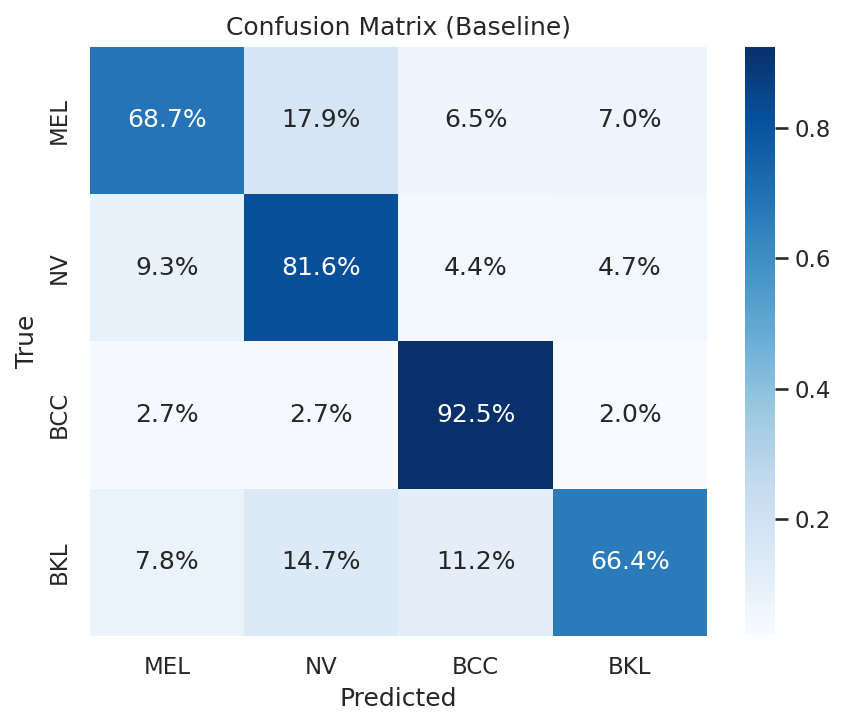

Evaluating models:  50%|█████     | 1/2 [1:10:44<1:10:44, 4244.13s/it]


  TRAINING: resnet101

 TRAINING: resnet101 (ISIC 2019)
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth



  0%|          | 0.00/171M [00:00<?, ?B/s]
  5%|▌         | 8.75M/171M [00:00<00:01, 91.2MB/s]
 16%|█▌        | 26.9M/171M [00:00<00:01, 149MB/s] 
 30%|██▉       | 50.6M/171M [00:00<00:00, 194MB/s]
 43%|████▎     | 74.0M/171M [00:00<00:00, 214MB/s]
 57%|█████▋    | 97.2M/171M [00:00<00:00, 225MB/s]
 70%|███████   | 120M/171M [00:00<00:00, 230MB/s] 
 84%|████████▍ | 143M/171M [00:00<00:00, 233MB/s]
100%|██████████| 171M/171M [00:00<00:00, 213MB/s]


resnet101: 42.51M params (42.51M trainable)
Epoch 1/15 | resnet101
  TRAIN loss: 0.7371 | acc: 0.624
  VAL   loss: 0.7637 | acc: 0.639 | F1: 0.6373 | AUC: 0.9009 | ECE: 0.1166
  ✅ Saved best model (F1=0.6373): /kaggle/working/checkpoints/best_isic_resnet101.pth
Epoch 2/15 | resnet101
  TRAIN loss: 0.4270 | acc: 0.771
  VAL   loss: 0.6918 | acc: 0.694 | F1: 0.6797 | AUC: 0.9143 | ECE: 0.1002
  ✅ Saved best model (F1=0.6797): /kaggle/working/checkpoints/best_isic_resnet101.pth
Epoch 3/15 | resnet101
  TRAIN loss: 0.3203 | acc: 0.825
  VAL   loss: 0.6769 | acc: 0.714 | F1: 0.7054 | AUC: 0.9237 | ECE: 0.1132
  ✅ Saved best model (F1=0.7054): /kaggle/working/checkpoints/best_isic_resnet101.pth
Epoch 4/15 | resnet101
  TRAIN loss: 0.2337 | acc: 0.864
  VAL   loss: 0.6516 | acc: 0.740 | F1: 0.7276 | AUC: 0.9371 | ECE: 0.1164
  ✅ Saved best model (F1=0.7276): /kaggle/working/checkpoints/best_isic_resnet101.pth
Epoch 5/15 | resnet101
  TRAIN loss: 0.1907 | acc: 0.887
  VAL   loss: 0.6407 | acc:

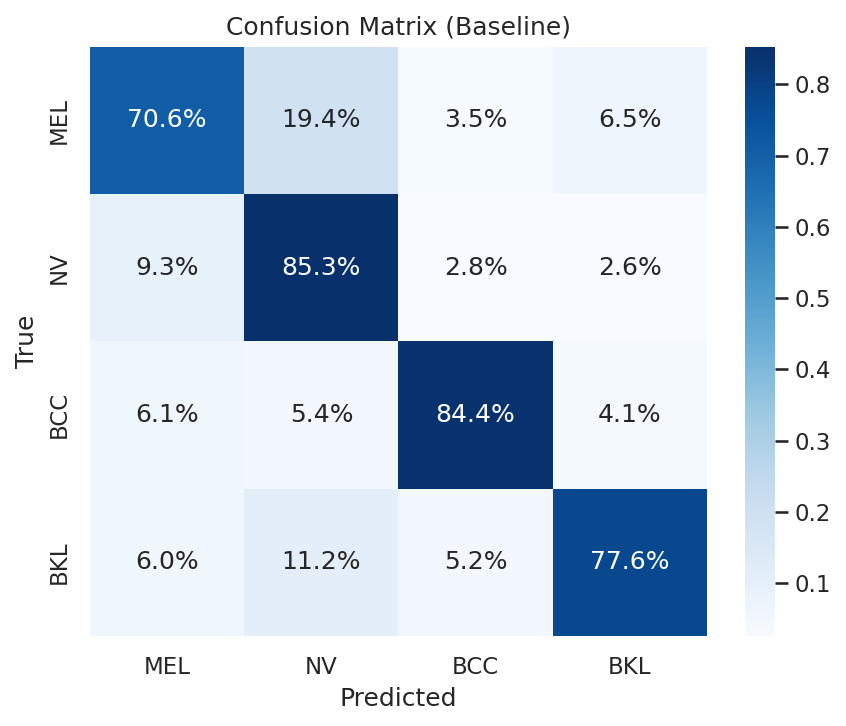

Evaluating models: 100%|██████████| 2/2 [2:22:28<00:00, 4274.17s/it]



✅ Baseline results saved: /kaggle/working/results/baseline_results.csv


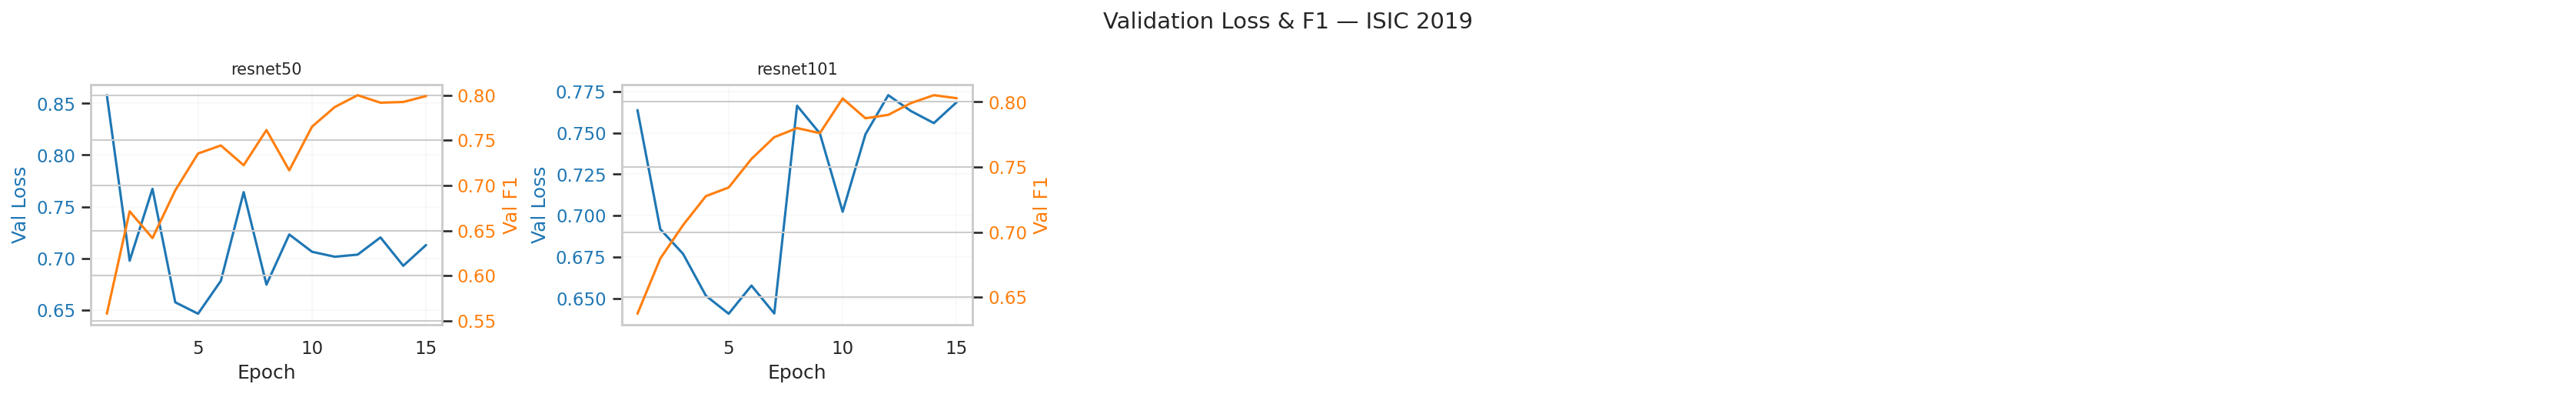

📈 Training curves saved: /kaggle/working/figures/fig2_training_curves.png

 FINAL TEST PERFORMANCE — ISIC 2019
    model  test_accuracy  test_f1  test_auc  test_ece
 resnet50         0.7894   0.7494    0.9394    0.1116
resnet101         0.8145   0.7843    0.9391    0.1129

--------------------------------------------------------------------------------
 BEST F1       : resnet101
 BEST Accuracy : resnet101
 BEST AUC      : resnet50
 BEST ECE      : resnet50
✓ Section 6 complete


In [9]:
# =====================================
# Section 6: Baseline Model Evaluation & Results Aggregation
# Fully aligned with final pipeline (shared with Kvasir, BUSI, COVID)
# =====================================
import gc
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path

# =====================================
# Initialize storage
# =====================================
all_histories = {}           # Training curves by model
baseline_results = []        # Final performance results
baseline_confusions = {}     # Confusion matrices

# Loss function (on device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Ensure output directories exist
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Starting baseline evaluation: {len(MODELS)} models | ISIC 2019")
print("=" * 80)

# ───────────────────────────────────────────────────────────────────────
# Loop: Train and evaluate each model
# ───────────────────────────────────────────────────────────────────────
for model_name in tqdm(MODELS, desc="Evaluating models"):
    print(f'\n{"="*60}')
    print(f"  TRAINING: {model_name}")
    print(f'{"="*60}')

    # Train model (returns best weights loaded)
    try:
        model, history, best_val_metrics = train_model(
            model_name, train_loader, val_loader, class_weights, CONFIG
        )
        all_histories[model_name] = history
    except Exception as e:
        print(f"  ❌ Failed to train {model_name}: {e}")
        continue

    # Load best checkpoint (redundant but safe)
    ckpt_path = f'{CONFIG["checkpoint_dir"]}/best_isic_{model_name}.pth'
    if not Path(ckpt_path).exists():
        print(f"  ❌ Checkpoint not saved: {ckpt_path}")
        continue

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    # Final evaluation on test set
    print("  🔍 Running final test evaluation...")
    test_metrics = evaluate(
        model, test_loader, criterion, device,
        CONFIG['num_classes'], CONFIG['class_names']
    )

    # Extract labels and predictions
    y_true = test_metrics['labels'].astype(int)
    y_pred = test_metrics['preds'].astype(int)
    ece = test_metrics['ece']

    # Confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(CONFIG['num_classes']))
    )
    baseline_confusions[model_name] = cm

    # Per-class metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(CONFIG['num_classes'])),
        zero_division=0
    )

    # Add per-class metrics
    per_class_metrics = {}
    for i, name in enumerate(CONFIG['class_names']):
        per_class_metrics[f'{name}_precision'] = float(precision[i])
        per_class_metrics[f'{name}_recall']    = float(recall[i])
        per_class_metrics[f'{name}_f1']        = float(f1[i])

    # Append row to results
    baseline_results.append({
        'model': model_name,
        'val_acc': best_val_metrics.get('val_acc', float('nan')),
        'val_f1': best_val_metrics.get('val_f1', float('nan')),
        'val_auc': best_val_metrics.get('val_auc', float('nan')),
        'val_ece': best_val_metrics.get('val_ece', float('nan')),
        'test_accuracy': test_metrics['accuracy'],
        'test_f1': test_metrics['f1'],
        'test_auc': test_metrics['auc'],
        'test_ece': ece,
        **per_class_metrics
    })

    # Save confusion matrix
    plot_confusion_matrix(
        cm=cm,
        class_names=CONFIG['class_names'],
        model_name=model_name,
        save=True,
        suffix='baseline'
    )

    # Cleanup GPU memory
    del model
    torch.cuda.empty_cache()
    gc.collect()


# ───────────────────────────────────────────────────────────────────────
# 1. Save: baseline_results.csv
# ───────────────────────────────────────────────────────────────────────
if len(baseline_results) == 0:
    print("❌ No models evaluated — cannot save results.")
else:
    baseline_df = pd.DataFrame(baseline_results)
    save_path = f"{CONFIG['results_dir']}/baseline_results.csv"
    baseline_df.to_csv(save_path, index=False)
    print(f"\n✅ Baseline results saved: {save_path}")

    # ───────────────────────────────────────────────────────────────────────
    # 2. Plot: Training Curves (Val Loss + Val F1 per model)
    # ───────────────────────────────────────────────────────────────────────
    ncols = 5
    nrows = (len(MODELS) + ncols - 1) // ncols  # Ceiling division
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 4.5, nrows * 3.5),
        dpi=150
    )

    # Handle edge case: single row or single column
    if nrows == 1:
        axes = np.array([axes]) if ncols > 1 else np.array([[axes]])
    elif ncols == 1:
        axes = axes.reshape(-1)

    axes_flat = axes.flat

    for ax, model_name in zip(axes_flat, MODELS):
        hist = all_histories.get(model_name, {})

        epochs = np.arange(1, len(hist.get('val_loss', [])) + 1)

        if len(epochs) == 0:
            ax.axis('off')
            continue

        # Left axis: Val Loss (blue)
        ax.plot(epochs, hist.get('val_loss', []), color='tab:blue', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Loss', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax.grid(True, alpha=0.1)

        # Right axis: Val F1 (orange)
        ax2 = ax.twinx()
        ax2.plot(epochs, hist.get('val_f1', []), color='tab:orange', label='Val F1')
        ax2.set_ylabel('Val F1', color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange')

        ax.set_title(model_name, fontsize=10)

    # Turn off unused subplots
    for ax in axes_flat[len(MODELS):]:
        ax.axis('off')

    plt.suptitle("Validation Loss & F1 — ISIC 2019", fontsize=14, y=0.97)
    plt.tight_layout()
    fig_path = f"{CONFIG['figures_dir']}/fig2_training_curves.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"📈 Training curves saved: {fig_path}")

    # ───────────────────────────────────────────────────────────────────────
    # 3. Print: Final Performance Table
    # ───────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 80)
    print(" FINAL TEST PERFORMANCE — ISIC 2019")
    print("=" * 80)
    result_columns = ['model', 'test_accuracy', 'test_f1', 'test_auc', 'test_ece']
    print(
        baseline_df[result_columns]
        .round(4)
        .to_string(index=False)
    )

    # ───────────────────────────────────────────────────────────────────────
    # 4. Summary: Best model by each metric
    # ───────────────────────────────────────────────────────────────────────
    print("\n" + "-" * 80)
    try:
        best_f1_model = baseline_df.loc[baseline_df['test_f1'].idxmax(), 'model']
        best_acc_model = baseline_df.loc[baseline_df['test_accuracy'].idxmax(), 'model']
        best_auc_model = baseline_df.loc[baseline_df['test_auc'].idxmax(), 'model']
        best_ece_model = baseline_df.loc[baseline_df['test_ece'].idxmin(), 'model']

        print(f" BEST F1       : {best_f1_model}")
        print(f" BEST Accuracy : {best_acc_model}")
        print(f" BEST AUC      : {best_auc_model}")
        print(f" BEST ECE      : {best_ece_model}")
    except Exception as e:
        print(f"  ⚠️ Could not identify best models: {e}")

print("✓ Section 6 complete")

In [10]:
# =====================================
# Section 7: Failure Sample Extraction & Embedding Capture
# Aligned with unified pipeline (shared across Kvasir, BUSI, COVID)
# =====================================
import gc
import pandas as pd
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm


def extract_failures(model_name: str, loader, config):
    """
    Run inference using the best checkpoint, extract predictions, confidence,
    embeddings, and probability vectors.

    Parameters:
        model_name: str
        loader: DataLoader (typically val_loader, to avoid test leakage)
        config: dict (with checkpoint_dir, etc.)

    Returns:
        failures_df: DataFrame of misclassified samples
        all_preds_df: DataFrame of all predictions
    """
    model = get_model(model_name, config['num_classes'], pretrained=False)
    ckpt_path = f"{config['checkpoint_dir']}/best_isic_{model_name}.pth"

    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    # Attach hook to capture penultimate-layer embedding
    hook_handle, embedding_store = get_embedding_hook(model, model_name)

    rows = []
    with torch.no_grad():
        for images, labels, paths in tqdm(
            loader,
            desc=f"extract {model_name}",
            leave=False,
            disable=not config.get('show_batch_progress', False)
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            conf = probs.max(axis=1)
            emb_batch = embedding_store['embedding'].numpy()  # (B, D)

            # Collect per-sample records
            for i in range(len(paths)):
                rows.append({
                    'image_path': paths[i],
                    'true_label': int(labels.cpu().numpy()[i]),
                    'pred_label': int(preds[i]),
                    'confidence': float(conf[i]),
                    'prob_vector': ','.join([f'{p:.8f}' for p in probs[i]]),
                    'embedding': ','.join([f'{x:.8f}' for x in emb_batch[i].ravel()]),
                })

    # Remove hook to avoid memory/callback conflicts
    hook_handle.remove()

    # Convert to DataFrames
    all_preds_df = pd.DataFrame(rows)
    failures_df = all_preds_df[all_preds_df['true_label'] != all_preds_df['pred_label']].reset_index(drop=True)

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return failures_df, all_preds_df


# ─────────────────────────────────────────────────────────────────────
# Run: Extract Failures on VAL Set (Aligned with Final Pipeline)
# ─────────────────────────────────────────────────────────────────────
all_failures = {}
all_predictions = {}

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Extracting failure samples for {len(MODELS)} models — ISIC 2019 (using VAL set)")
print("=" * 80)

for model_name in tqdm(MODELS, desc="Extracting failures"):
    try:
        # ✅ Use val_loader: faster, avoids test-set overuse
        failures_df, all_preds_df = extract_failures(model_name, val_loader, CONFIG)

        # Store in global dicts
        all_failures[model_name] = failures_df
        all_predictions[model_name] = all_preds_df

        # Save full and failure-only predictions
        failures_csv = f"{CONFIG['results_dir']}/failures_isic_{model_name}.csv"
        preds_csv = f"{CONFIG['results_dir']}/predictions_isic_{model_name}.csv"

        failures_df.to_csv(failures_csv, index=False)
        all_preds_df.to_csv(preds_csv, index=False)

        # Log summary
        total = len(all_preds_df)
        failed = len(failures_df)
        fail_rate = failed / max(total, 1)
        print(f"{model_name}: {failed:,} failures ({fail_rate:.1%})")

    except Exception as e:
        print(f"❌ Failed to extract failures for {model_name}: {e}")


print("✓ Section 7 complete")


✓ Extracting failure samples for 2 models — ISIC 2019 (using VAL set)


Extracting failures:   0%|          | 0/2 [00:00<?, ?it/s]

resnet50: 23.52M params (23.52M trainable)


Extracting failures:  50%|█████     | 1/2 [00:08<00:08,  8.51s/it]

resnet50: 178 failures (17.2%)
resnet101: 42.51M params (42.51M trainable)


Extracting failures: 100%|██████████| 2/2 [00:18<00:00,  9.14s/it]

resnet101: 172 failures (16.6%)
✓ Section 7 complete



🔍 Running failure clustering for 2 models — ISIC 2019 Dataset


Clustering Models:   0%|          | 0/2 [00:00<?, ?it/s]

  🌀 [resnet50] Clustering 178 failure samples
  ✅ Parsed 178 × 2048d | 0.05s
  📉 PCA-32d → explained variance: 0.667 | 0.46s
  🗺️  PCA-2D-2D projection computed | 0.00s
  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] completed | 0.27s
  ✅ Final clustering (K=2) | 0.01s
  🧪 Clustering stability (ARI): [0.9773704170795358, 0.9773704170795358, 0.6112123196655096] → mean=0.855


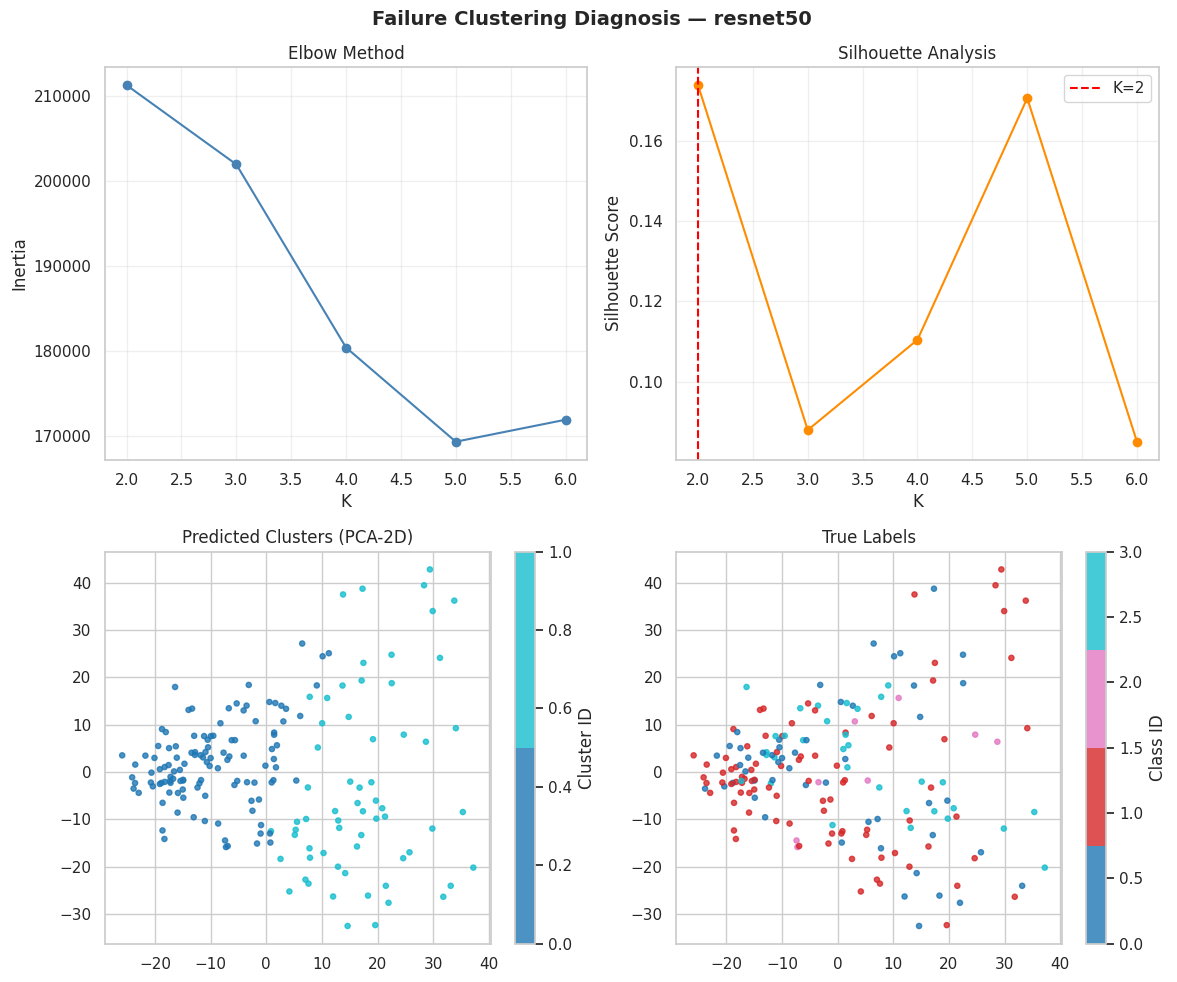

Clustering Models:  50%|█████     | 1/2 [00:02<00:02,  2.74s/it]

  📤 Diagnostic plot saved: /kaggle/working/figures/clustering_isic_resnet50.png
  🕐 TOTAL clustering time: 2.64s
  ✅ Clusters exported: K=2, 178 samples → /kaggle/working/results/clustered_failures_isic_resnet50.csv
  🌀 [resnet101] Clustering 172 failure samples
  ✅ Parsed 172 × 2048d | 0.05s
  📉 PCA-32d → explained variance: 0.655 | 0.05s
  🗺️  PCA-2D-2D projection computed | 0.00s
  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] completed | 0.14s
  ✅ Final clustering (K=2) | 0.01s
  🧪 Clustering stability (ARI): [0.08133690371335817, 0.08133690371335817, 0.07127594492273046] → mean=0.078


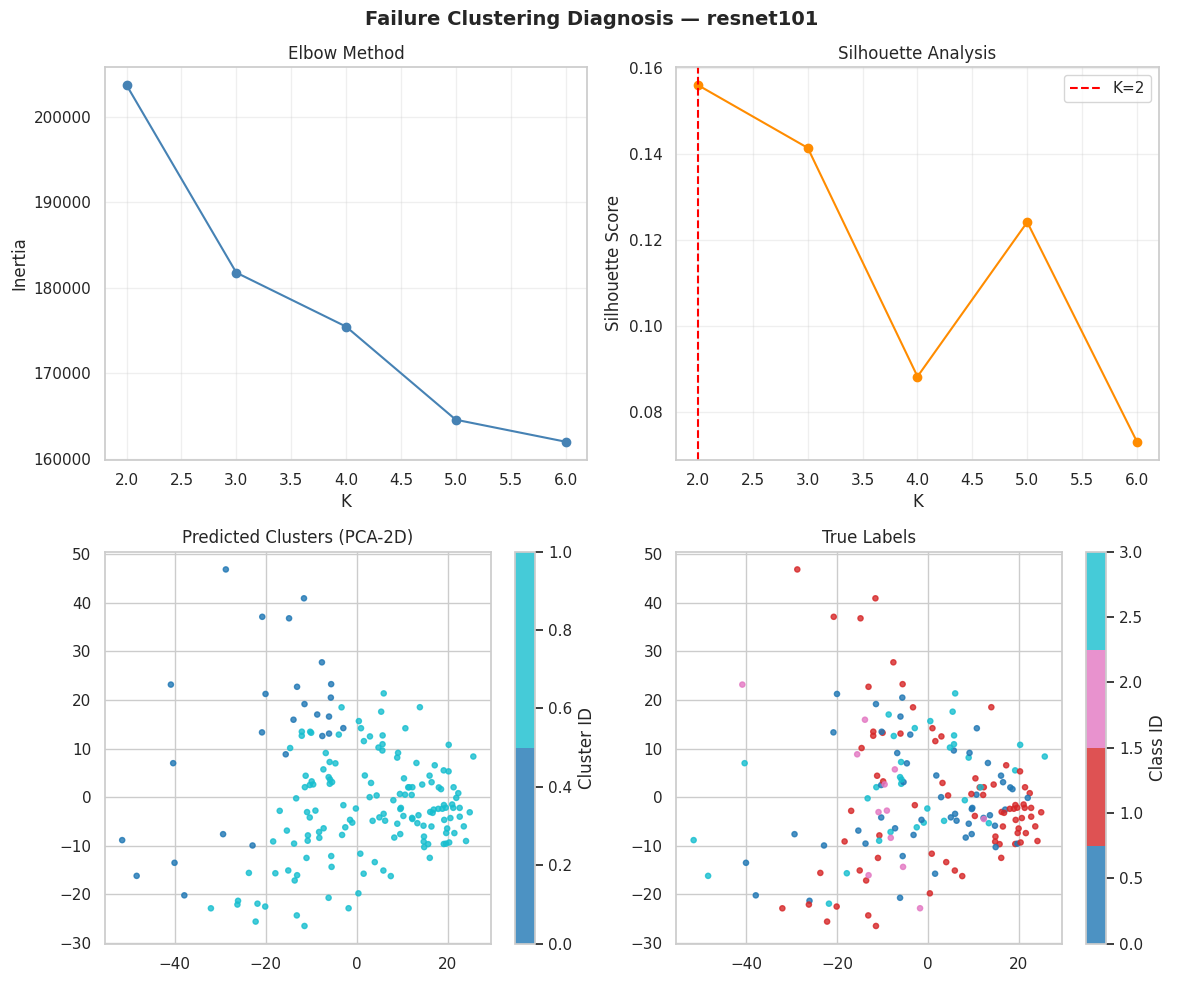

Clustering Models: 100%|██████████| 2/2 [00:04<00:00,  2.44s/it]

  📤 Diagnostic plot saved: /kaggle/working/figures/clustering_isic_resnet101.png
  🕐 TOTAL clustering time: 2.03s
  ✅ Clusters exported: K=2, 172 samples → /kaggle/working/results/clustered_failures_isic_resnet101.csv

✓ Section 8 complete — Failure clustering pipeline finished
  Results saved to: /kaggle/working/results
  Diagnostic plots in: /kaggle/working/figures


In [11]:
# =====================================
# Section 8: Failure Clustering
# Aligned with final pipeline (shared across Kvasir, BUSI, COVID)
# =====================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap as umap_lib
from tqdm import tqdm
import gc

# Ensure critical globals exist
assert 'CONFIG' in globals(), "CONFIG must be defined (with seed, figures_dir, etc.)"
assert 'all_failures' in globals(), "all_failures dict must contain failed predictions"
assert 'MODELS' in globals(), "MODELS list must be defined"


def cluster_failures(failures_df, config, model_name):
    """
    Cluster misclassified validation samples using:
      - PCA → MiniBatchKMeans
      - UMAP for visualization if failure count >= threshold
      - Silhouette optimization to select best K
      - Stability estimation via ARI across seeds

    Returns:
        clustered_df: DataFrame with cluster / UMAP / metadata
        best_k: optimal number of clusters
        best_sil: best silhouette score
        mean_ari: clustering stability (average Adjusted Rand Index)
        best_k_bic: placeholder (same as best_k)
    """
    t0 = time.time()

    # ── Guard: Not enough samples ─────────────────────────────────────
    if len(failures_df) < 3:
        print(f"  🛑 Too few failures ({len(failures_df)}) — skipping: {model_name}")
        out = failures_df.copy()
        out['cluster'] = 0
        out['umap_x'] = 0.0
        out['umap_y'] = 0.0
        out['mean_ari'] = np.nan
        return out, 1, np.nan, np.nan, 1

    print(f"  🌀 [{model_name}] Clustering {len(failures_df)} failure samples")

    # ── Parse embeddings ──────────────────────────────────────────────
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array([
            np.fromstring(e, sep=',', dtype=np.float32) for e in raw
        ], dtype=np.float32)
    else:
        embeddings = np.array(raw, dtype=np.float32)
    print(f"  ✅ Parsed {len(failures_df)} × {embeddings.shape[1]}d | {time.time()-t0:.2f}s")

    # ── PCA: Dimensionality Reduction ───────────────────────────────
    t1 = time.time()
    scaler = StandardScaler()
    E_scaled = scaler.fit_transform(embeddings)

    n_pca = min(
        config.get('pca_components', 32),
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(n_components=n_pca, random_state=config['seed'], svd_solver='randomized')
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    var_ratio = pca.explained_variance_ratio_.sum()
    print(f"  📉 PCA-{n_pca}d → explained variance: {var_ratio:.3f} | {time.time()-t1:.2f}s")

    # ── UMAP: 2D Projection for Visualization ────────────────────────
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)
    input_for_umap = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca

    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        reducer = umap_lib.UMAP(
            n_neighbors=min(10, max(2, len(failures_df) - 1)),
            min_dist=config.get('umap_min_dist', 0.1),
            n_components=2,
            random_state=config['seed'],
            n_epochs=50,
            metric='euclidean',
            low_memory=True,
            n_jobs=1
        )
        E_2d = reducer.fit_transform(input_for_umap).astype(np.float32)
        proj_method = 'UMAP'
    print(f"  🗺️  {proj_method}-2D projection computed | {time.time()-t2:.2f}s")

    # ── KMeans Sweep: Select Best K via Silhouette ────────────────────
    t3 = time.time()
    k_range = list(config.get('k_range', range(2, 7)))
    k_range = [k for k in k_range if 2 <= k <= min(6, len(failures_df) - 1)]
    if not k_range:
        k_range = [2]

    inertias, silhouettes = [], []
    MAX_SIL_SAMPLES = 500

    # Subsample for faster silhouette score
    if len(E_pca) > MAX_SIL_SAMPLES:
        sil_idx = np.random.RandomState(config['seed']).choice(
            len(E_pca), size=MAX_SIL_SAMPLES, replace=False
        )
    else:
        sil_idx = np.arange(len(E_pca))
    E_sil = E_pca[sil_idx]

    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=config['seed'],
            n_init=3,
            batch_size=min(256, len(failures_df)),
            max_iter=100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)

        unique_labels = np.unique(labels[sil_idx])
        if len(unique_labels) > 1:
            s = silhouette_score(E_sil, labels[sil_idx])
        else:
            s = np.nan
        silhouettes.append(s)

    print(f"  🔍 KMeans sweep over K={k_range} completed | {time.time()-t3:.2f}s")

    # ── Select Best K ─────────────────────────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = np.nanargmax(silhouettes)
        best_k = k_range[best_idx]
        best_sil = silhouettes[best_idx]
    else:
        best_k = 2
        best_sil = np.nan

    # ── Final Clustering with Best K ──────────────────────────────────
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=config['seed'],
        n_init=5,
        batch_size=min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  ✅ Final clustering (K={best_k}) | {time.time()-t4:.2f}s")

    # ── Clustering Stability (ARI across seeds) ────────────────────────
    ari_scores = []
    seeds = [config['seed'], 42, 100]
    for seed in seeds:
        test_km = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labs = test_km.fit_predict(E_pca)
        ari = adjusted_rand_score(cluster_labels, labs)
        ari_scores.append(ari)
    mean_ari = float(np.mean(ari_scores))
    print(f"  🧪 Clustering stability (ARI): {ari_scores} → mean={mean_ari:.3f}")

    # ── Attach results ────────────────────────────────────────────────
    clustered_df = failures_df.copy().reset_index(drop=True)
    clustered_df['cluster'] = cluster_labels
    clustered_df['umap_x'] = E_2d[:, 0]
    clustered_df['umap_y'] = E_2d[:, 1]
    clustered_df['mean_ari'] = mean_ari

    # ── Diagnostic Plot: 2x2 Grid ─────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Elbow (Inertia)
    axes[0, 0].plot(k_range, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title('Elbow Method')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Silhouette Score
    axes[0, 1].plot(k_range, silhouettes, marker='o', color='darkorange')
    if best_sil == best_sil:  # not NaN
        axes[0, 1].axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette Score')
    axes[0, 1].set_title('Silhouette Analysis')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Cluster Assignments
    cmap_clusters = cm.get_cmap('tab10', best_k)
    sc1 = axes[1, 0].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['cluster'], cmap=cmap_clusters, s=14, alpha=0.8
    )
    axes[1, 0].set_title(f'Predicted Clusters ({proj_method})')
    plt.colorbar(sc1, ax=axes[1, 0], label='Cluster ID')

    # 4. True Labels
    cmap_labels = cm.get_cmap('tab10', len(config['class_names']))
    sc2 = axes[1, 1].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['true_label'], cmap=cmap_labels, s=14, alpha=0.8
    )
    axes[1, 1].set_title('True Labels')
    plt.colorbar(sc2, ax=axes[1, 1], label='Class ID')

    # Final layout
    plt.suptitle(f"Failure Clustering Diagnosis — {model_name}", fontsize=14, weight='bold')
    plt.tight_layout()

    # Save and show
    save_path = f"{config['figures_dir']}/clustering_isic_{model_name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  📤 Diagnostic plot saved: {save_path}")

    print(f"  🕐 TOTAL clustering time: {time.time()-t0:.2f}s")
    return clustered_df, best_k, best_sil, mean_ari, best_k  # best_k_bic = best_k (placeholder)


# ─────────────────────────────────────────────────────────────────────
# Run Clustering for All Models — ISIC 2019 Dataset
# ─────────────────────────────────────────────────────────────────────
all_clustered = {}        # Holds clustered DataFrames by model
cluster_summaries = {}    # Summarizes cluster quality metrics

# Create output directories
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n🔍 Running failure clustering for {len(MODELS)} models — ISIC 2019 Dataset")
print("=" * 80)

for model_name in tqdm(MODELS, desc="Clustering Models"):
    if model_name not in all_failures or len(all_failures[model_name]) == 0:
        print(f"  ❌ No failure data for {model_name}")
        continue

    try:
        clustered_df, best_k, best_sil, mean_ari, best_k_bic = cluster_failures(
            all_failures[model_name], CONFIG, model_name
        )

        # Store
        all_clustered[model_name] = clustered_df
        cluster_summaries[model_name] = {
            'best_k': int(best_k),
            'silhouette': float(best_sil) if not np.isnan(best_sil) else None,
            'mean_ari': float(mean_ari) if not np.isnan(mean_ari) else None,
            'best_k_bic': int(best_k_bic)
        }

        # Export clustered failures (ISIC-specific naming)
        export_path = f"{CONFIG['results_dir']}/clustered_failures_isic_{model_name}.csv"
        clustered_df.to_csv(export_path, index=False)
        print(f"  ✅ Clusters exported: K={best_k}, {len(clustered_df)} samples → {export_path}")

    except Exception as e:
        print(f"  ❌ Failed to cluster {model_name}: {type(e).__name__}: {e}")

print("\n✓ Section 8 complete — Failure clustering pipeline finished")
print(f"  Results saved to: {CONFIG['results_dir']}")
print(f"  Diagnostic plots in: {CONFIG['figures_dir']}")


✓ Profiling failure clusters for 2 models — ISIC 2019


Profiling clusters:   0%|          | 0/2 [00:00<?, ?it/s]


 Profiling → resnet50

  CLUSTER PROFILE SUMMARY
 cluster  n_samples dominant_confusion  mean_confidence  per_cluster_ece
       0        115             NV→MEL           0.7827           0.7827
       1         63             NV→BCC           0.8252           0.8252


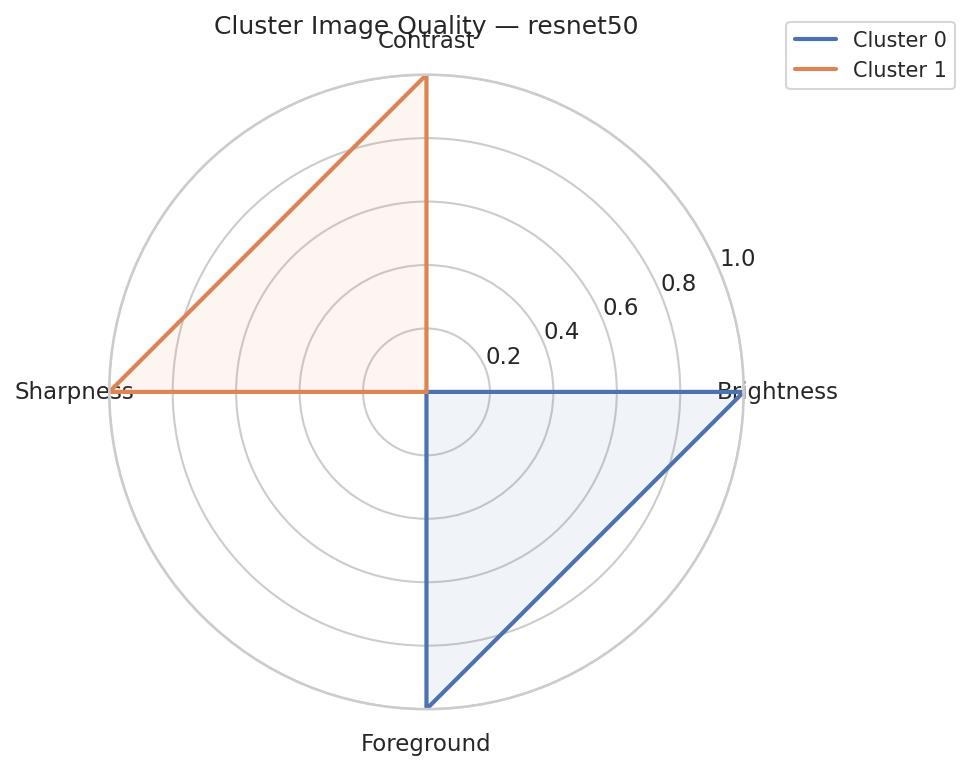

Profiling clusters:  50%|█████     | 1/2 [00:02<00:02,  2.60s/it]

  📊 Radar plot saved: /kaggle/working/figures/radar_isic_resnet50.png
  ✅ Profile saved: /kaggle/working/results/profile_isic_resnet50.csv

 Profiling → resnet101

  CLUSTER PROFILE SUMMARY
 cluster  n_samples dominant_confusion  mean_confidence  per_cluster_ece
       0         26             NV→BKL           0.8897           0.8897
       1        146             NV→MEL           0.8076           0.8076


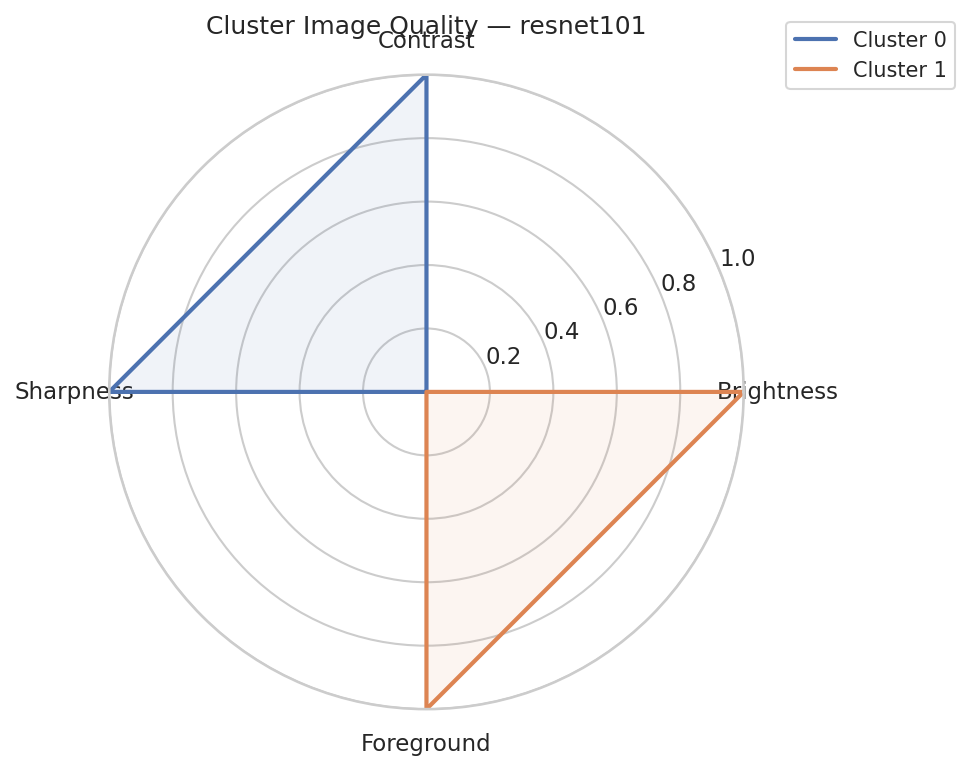

Profiling clusters: 100%|██████████| 2/2 [00:03<00:00,  1.95s/it]

  📊 Radar plot saved: /kaggle/working/figures/radar_isic_resnet101.png
  ✅ Profile saved: /kaggle/working/results/profile_isic_resnet101.csv

📊 Global feature cache: 246 unique images
✓ Section 9 complete


In [12]:
# =====================================
# Section 9: Failure Cluster Profiling
# Aligned with final pipeline: computes image quality, confusion, and calibration per cluster
# =====================================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from collections import Counter
# from tqdm import tqdm
# from scipy import ndimage
# from PIL import Image
# from pathlib import Path

# Global cache for expensive image features (shared across models)
IMAGE_FEATURE_CACHE = {}


def compute_image_features(image_path, image_dir=None):
    """
    Compute fast, modality-robust image features:
      - brightness (mean intensity / 255)
      - contrast (std / 255)
      - sharpness (Laplacian variance)
      - foreground_size (fraction above mean intensity)

    Returns: dict of metrics (or NaNs on failure).
    """
    if image_path in IMAGE_FEATURE_CACHE:
        return IMAGE_FEATURE_CACHE[image_path]

    try:
        img = Image.open(image_path).convert('L')  # Grayscale
        img = img.resize((224, 224), Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32)
    except Exception:
        features = {
            'brightness': np.nan,
            'contrast': np.nan,
            'sharpness': np.nan,
            'foreground_size': np.nan,
        }
        IMAGE_FEATURE_CACHE[image_path] = features
        return features

    # 1. Brightness: mean intensity normalized
    brightness = float(arr.mean() / 255.0)

    # 2. Contrast: standard deviation normalized
    contrast = float(arr.std() / 255.0)

    # 3. Sharpness: Laplacian variance (edge content)
    if ndimage is not None:
        sharpness = float(np.var(ndimage.laplace(arr)))
    else:
        gy, gx = np.gradient(arr)
        sharpness = float(np.var(gx) + np.var(gy))

    # 4. Foreground proxy: fraction above mean intensity
    if arr.std() > 1.0:  # Avoid flat fields
        foreground_size = float((arr > arr.mean()).mean())
    else:
        foreground_size = 0.0

    features = {
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'foreground_size': foreground_size,
    }

    IMAGE_FEATURE_CACHE[image_path] = features
    return features


def profile_clusters(clustered_df, model_name, config):
    """
    Compute per-cluster summary:
      - Confusion pattern (dominant true→pred)
      - Image quality: brightness, contrast, sharpness, foreground coverage
      - Confidence stats and cluster-level ECE

    Returns: DataFrame with one row per cluster.
    """
    rows = []

    if len(clustered_df) == 0:
        print(f"  🚫 No clustered failures for {model_name}")
        return pd.DataFrame()

    class_map = dict(enumerate(config['class_names']))

    for cluster_id, group in tqdm(
        clustered_df.groupby('cluster'),
        desc=f"profiling {model_name}",
        leave=False,
        disable=not config.get('show_batch_progress', False)
    ):
        # Convert string prob vectors into array
        probs = np.stack(
            group['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
        )
        labels_arr = group['true_label'].values

        # Dominant confusion pattern
        pairs = list(zip(group['true_label'], group['pred_label']))
        dominant_pair = Counter(pairs).most_common(1)[0][0]
        from_class = config['class_names'][dominant_pair[0]]
        to_class = config['class_names'][dominant_pair[1]]
        confusion_label = f"{from_class}→{to_class}"

        # Compute image quality per image
        feature_rows = [
            compute_image_features(p, config.get('image_dir'))
            for p in group['image_path']
        ]
        features_df = pd.DataFrame(feature_rows)

        # Build cluster-level summary
        row = {
            'cluster': int(cluster_id),
            'n_samples': int(len(group)),
            'true_class_distribution': dict(Counter(group['true_label'].map(class_map))),
            'pred_class_distribution': dict(Counter(group['pred_label'].map(class_map))),
            'dominant_confusion': confusion_label,
            'mean_confidence': float(group['confidence'].mean()),
            'std_confidence': float(group['confidence'].std(ddof=0)),
            'per_cluster_ece': compute_ece(probs, labels_arr, config['ece_bins']),
        }

        # Aggregate image features
        for feat in ['brightness', 'contrast', 'sharpness', 'foreground_size']:
            row[f'{feat}_mean'] = float(features_df[feat].mean())
            row[f'{feat}_std'] = float(features_df[feat].std(ddof=0))

        rows.append(row)

    profile_df = pd.DataFrame(rows)

    # ── Print Summary Table ──────────────────────────────────────────
    if not profile_df.empty:
        print("\n" + "=" * 60)
        print("  CLUSTER PROFILE SUMMARY")
        print("=" * 60)
        print(profile_df[[
            'cluster', 'n_samples', 'dominant_confusion',
            'mean_confidence', 'per_cluster_ece'
        ]].round(4).to_string(index=False))

    # ── Radar Plot: Normalize & Visualize Image Quality ──────────────
    feat_cols = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    labels = ['Brightness', 'Contrast', 'Sharpness', 'Foreground']
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]  # Close loop

    if not profile_df.empty:
        radar = profile_df[['cluster'] + feat_cols].copy().reset_index(drop=True)

        # Normalize features across clusters
        for feat in feat_cols:
            mn, mx = radar[feat].min(), radar[feat].max()
            if pd.isna(mn) or pd.isna(mx) or mx <= mn:
                radar[feat] = 0.5
            else:
                radar[feat] = (radar[feat] - mn) / (mx - mn)

        # Plot
        fig = plt.figure(figsize=(7, 7), dpi=150)
        ax = fig.add_subplot(111, polar=True)

        for idx, row in radar.iterrows():
            values = [row[feat] for feat in feat_cols] + [row[feat_cols[0]]]
            ax.plot(angles, values, linewidth=2, label=f"Cluster {int(row['cluster'])}")
            ax.fill(angles, values, alpha=0.08)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1)
        ax.set_title(f"Cluster Image Quality — {model_name}", pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

        plt.tight_layout()
        save_path = f"{config['figures_dir']}/radar_isic_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  📊 Radar plot saved: {save_path}")
    else:
        print("  📉 No clusters → Skipping radar plot")

    return profile_df


# ─────────────────────────────────────────────────────────────────────
# Run Profiling for All Models — ISIC 2019
# ─────────────────────────────────────────────────────────────────────
all_profiles = {}

# Ensure output directories
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Profiling failure clusters for {len(MODELS)} models — ISIC 2019")
print("=" * 80)

for model_name in tqdm(MODELS, desc='Profiling clusters'):
    if model_name not in all_clustered or len(all_clustered[model_name]) == 0:
        print(f"  ❌ No clustered data for {model_name}")
        continue

    try:
        print(f'\n{"="*50}')
        print(f' Profiling → {model_name}')
        print(f'{"="*50}')

        profile_df = profile_clusters(all_clustered[model_name], model_name, CONFIG)
        all_profiles[model_name] = profile_df

        # Save profile CSV
        save_path = f'{CONFIG["results_dir"]}/profile_isic_{model_name}.csv'
        profile_df.to_csv(save_path, index=False)
        print(f"  ✅ Profile saved: {save_path}")

    except Exception as e:
        print(f"  ❌ Failed to profile {model_name}: {type(e).__name__}: {e}")

# Final cache report
print(f"\n📊 Global feature cache: {len(IMAGE_FEATURE_CACHE)} unique images")
print("✓ Section 9 complete")

In [13]:
# =====================================
# Section 10: Failure-Aware Retraining & Degradation Guard
# Aligned with final unified pipeline (shared with Kvasir, BUSI, COVID)
# =====================================
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# ─────────────────────────────────────────────────────────────────────
# 1. Build Failure-Aware Training Set
# ─────────────────────────────────────────────────────────────────────
def build_failure_aware_dataset(train_df, clustered_df, profile_df, config, strategy='both'):
    """
    Enhance training set using failure cluster insights:
      - Selective augmentation: augment high-failure clusters
      - Weighted sampling: upweight failure-prone samples or classes
      - Both: apply both enhancements
    """
    out = train_df.copy()
    out['is_augmented'] = False
    out['sample_weight'] = 1.0

    if (clustered_df is None or len(clustered_df) == 0 or
        profile_df is None or len(profile_df) == 0):
        return out

    # Cluster frequency scaling factor
    cluster_counts = clustered_df['cluster'].value_counts().to_dict()
    mean_cluster_count = np.mean(list(cluster_counts.values())) if cluster_counts else 1.0

    cluster_alpha = {
        k: max(1.0, v / max(mean_cluster_count, 1e-8))
        for k, v in cluster_counts.items()
    }

    # Mappings
    path_to_cluster = dict(zip(clustered_df['image_path'], clustered_df['cluster']))
    cluster_to_true_labels = (
        clustered_df
        .groupby('cluster')['true_label']
        .apply(lambda s: set(s.tolist()))
        .to_dict()
    )

    path_overlap = out['image_path'].isin(set(clustered_df['image_path'])).sum()

    # ── Selective Augmentation (for CNNs) ───────────────────────────────
    if strategy in ['selective', 'both']:
        high_clusters = [k for k, v in cluster_counts.items() if v > mean_cluster_count]
        if not high_clusters:
            high_clusters = list(cluster_counts.keys())

        high_paths = set(clustered_df[clustered_df['cluster'].isin(high_clusters)]['image_path'])
        source = out[out['image_path'].isin(high_paths)].copy()

        # Fall back to class-level if no path overlap
        if len(source) == 0:
            high_labels = set()
            for cluster_id in high_clusters:
                high_labels.update(cluster_to_true_labels.get(cluster_id, set()))
            source = out[out['label'].isin(high_labels)].copy()
            print(
                "No train/test path overlap for selective augmentation; "
                f"using high-error true labels: {sorted(high_labels)}"
            )

        max_aug_source = config.get('max_aug_source', 300)
        if len(source) > max_aug_source:
            if source['label'].nunique() > 1:
                source, _ = train_test_split(
                    source,
                    train_size=max_aug_source,
                    random_state=config['seed'],
                    stratify=source['label']
                )
                source = source.reset_index(drop=True)
            else:
                source = source.sample(n=max_aug_source, random_state=config['seed']).reset_index(drop=True)
            print(f"Selective source limited to {max_aug_source} samples.")

        # Create augmented copies
        augmented = [source.copy() for _ in range(config.get('aug_multiplier', 3))]
        for a in augmented:
            a['is_augmented'] = True

        out = pd.concat([out] + augmented, ignore_index=True)
        print(
            f"Selective augmentation: {len(source)} source → "
            f"{len(augmented) * len(source)} augmented rows added"
        )

    # ── Weighted Sampling (for Transformers, EfficientNet) ───────────
    if strategy in ['weighted', 'both']:
        if path_overlap > 0:
            out['sample_weight'] = out['image_path'].map(
                lambda p: cluster_alpha.get(path_to_cluster.get(p, None), 1.0)
            )
        else:
            # Class-level weights
            label_weights = defaultdict(lambda: 1.0)
            for cluster_id, alpha in cluster_alpha.items():
                for label in cluster_to_true_labels.get(cluster_id, set()):
                    label_weights[label] = max(label_weights[label], alpha)
            out['sample_weight'] = out['label'].map(lambda y: label_weights[y])
            print(
                "No path overlap — using per-class weights: "
                f"{dict(label_weights)}"
            )

        print(
            f"Weighted sampling: weights {out['sample_weight'].min():.2f}–{out['sample_weight'].max():.2f}"
        )

    return out


# ─────────────────────────────────────────────────────────────────────
# 2. Degradation Guard (Tiered by Baseline F1)
# ─────────────────────────────────────────────────────────────────────
def _run_degradation_guard(
    model, model_name, val_loader, criterion_retrain,
    baseline_val_metrics, config, device,
    baseline_ckpt, retrained_ckpt
):
    """
    Evaluate retrained model and revert to baseline if degradation detected.
    Uses tiered thresholds based on baseline performance.
    """
    val_retrained = evaluate(
        model, val_loader, criterion_retrain,
        device, config['num_classes'], config['class_names']
    )

    baseline_f1 = baseline_val_metrics['val_f1']
    use_weak = baseline_f1 < config.get('guard_weak_baseline_f1', 0.55)

    # Set thresholds
    if use_weak:
        max_f1_drop = config.get('guard_weak_f1_max_drop', 0.005)
        max_acc_drop = config.get('guard_weak_acc_max_drop', 0.010)
        max_ece_rise = config.get('guard_weak_ece_max_rise', 0.025)
        tier = 'WEAK'
    else:
        max_f1_drop = config.get('guard_f1_max_drop', 0.000)
        max_acc_drop = config.get('guard_acc_max_drop', 0.005)
        max_ece_rise = config.get('guard_ece_max_rise', 0.010)
        tier = 'STRICT'

    f1_drop = baseline_val_metrics['val_f1'] - val_retrained['f1']
    acc_drop = baseline_val_metrics['val_acc'] - val_retrained['accuracy']
    ece_rise = val_retrained['ece'] - baseline_val_metrics['val_ece']

    checks = {
        'f1_ok': (
            f1_drop <= max_f1_drop,
            f"val F1 drop {f1_drop:+.4f} {'≤' if f1_drop <= max_f1_drop else '>'} {max_f1_drop} [{tier}]"
        ),
        'acc_ok': (
            acc_drop <= max_acc_drop,
            f"acc drop {acc_drop:+.4f} {'≤' if acc_drop <= max_acc_drop else '>'} {max_acc_drop} [{tier}]"
        ),
        'ece_ok': (
            ece_rise <= max_ece_rise,
            f"ECE rise {ece_rise:+.4f} {'≤' if ece_rise <= max_ece_rise else '>'} {max_ece_rise} [{tier}]"
        ),
    }

    print(f"  Guard checks — {model_name}:")
    for name, (passed, msg) in checks.items():
        print(f"    {'✓' if passed else '✗'}  {msg}")

    failed = [msg for passed, msg in checks.values() if not passed]
    if not failed:
        print(f"\n  ✓ All checks passed — keeping retrained {model_name}")
        return {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {k: v[1] for k, v in checks.items()},
            'reason': None,
        }

    print(f"\n  ⚠️ Degradation guard triggered — reverting {model_name}")
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    torch.save(model.state_dict(), retrained_ckpt)  # keep file consistent
    return {
        'guard_triggered': True,
        'kept': 'baseline',
        'checks': {k: v[1] for k, v in checks.items()},
        'reason': ' | '.join(failed),
    }


# ─────────────────────────────────────────────────────────────────────
# 3. Main Retraining Routine
# ─────────────────────────────────────────────────────────────────────
def retrain_model(
    model_name, train_loader_new, val_loader, class_weights, config,
    baseline_val_metrics=None
):
    """
    Warm-start from baseline and retrain using failure-aware data.
    Applies degradation guard to decide whether to keep or revert.
    """
    baseline_ckpt = Path(config['checkpoint_dir']) / f"best_isic_{model_name}.pth"
    retrained_ckpt = Path(config['checkpoint_dir']) / f"retrained_isic_{model_name}.pth"

    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    criterion_retrain = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = GradScaler()  # Mixed-precision

    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)

    for epoch in range(1, retrain_epochs + 1):
        print(f"  Retrain epoch {epoch}/{retrain_epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader_new, optimizer,
            criterion_retrain, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion_retrain, device,
            config['num_classes'], config['class_names']
        )
        scheduler.step()

        # Log
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_ece'].append(val_metrics['ece'])

        print(
            f"    loss={val_metrics['loss']:.4f}  "
            f"acc={val_metrics['accuracy']:.4f}  "
            f"F1={val_metrics['f1']:.4f}  "
            f"AUC={val_metrics['auc']:.4f}  "
            f"ECE={val_metrics['ece']:.4f}"
        )

        # Save best model
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), retrained_ckpt)
            print(f"    ✓ Checkpoint saved (F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    → Patience {patience_counter}/{retrain_patience}")
            if patience_counter >= retrain_patience:
                print(f"    🔚 Early stopping at epoch {epoch}")
                break

    # Load best checkpoint before guard
    model.load_state_dict(torch.load(retrained_ckpt, map_location=device))

    # Run guard
    if baseline_val_metrics is not None:
        guard_result = _run_degradation_guard(
            model, model_name, val_loader, criterion_retrain,
            baseline_val_metrics, config, device, baseline_ckpt, retrained_ckpt
        )
    else:
        print(f"\n  ⚠️ Warning: no baseline metrics — guard skipped for {model_name}")
        guard_result = {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {},
            'reason': 'Guard skipped — missing baseline F1/Acc/ECE'
        }

    return model, dict(history), guard_result


# ─────────────────────────────────────────────────────────────────────
# Run: Retraining (Section 10) — ISIC 2019
# ─────────────────────────────────────────────────────────────────────
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

improvement_results = []
retrain_histories = {}
retrained_confusions = {}
retrained_predictions = {}
guard_log = []

for model_name in tqdm(MODELS, desc='Retraining'):
    family = get_model_family(model_name)
    strategy = {
        'transformer': 'both',
        'efficient': 'weighted',
        'cnn': 'selective'
    }[family]

    print(f'\n{"═"*60}')
    print(f"Retraining → {model_name} | family={family} | strategy={strategy}")
    print(f'{"═"*60}')

    # Build enhanced dataset
    new_train_df = build_failure_aware_dataset(
        train_df,
        all_clustered[model_name],
        all_profiles[model_name],
        CONFIG,
        strategy
    )

    # Create new loader
    new_train_loader, _, _, _ = get_dataloaders(
        new_train_df, test_df, CONFIG, val_df=val_loader.dataset.df
    )

    # Baseline metrics (prefer val, fall back to test)
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    baseline_val_metrics = {
        'val_f1' : baseline_row.get('val_f1',  baseline_row['test_f1']),
        'val_acc': baseline_row.get('val_acc', baseline_row['test_accuracy']),
        'val_ece': baseline_row.get('val_ece', baseline_row['test_ece']),
    }

    # Retrain + Guard
    retrained_model, history, guard_result = retrain_model(
        model_name,
        new_train_loader,
        val_loader,
        class_weights,
        CONFIG,
        baseline_val_metrics=baseline_val_metrics
    )

    retrain_histories[model_name] = history
    guard_log.append({**guard_result, 'model': model_name})

    # Final test evaluation
    retrain_metrics = evaluate(
        retrained_model,
        test_loader,
        criterion,
        device,
        CONFIG['num_classes'],
        CONFIG['class_names']
    )
    retrained_predictions[model_name] = retrain_metrics

    # Confusion matrix
    retrained_confusions[model_name] = confusion_matrix(
        retrain_metrics['labels'],
        retrain_metrics['preds'],
        labels=list(range(CONFIG['num_classes']))
    )

    # Compute deltas
    def delta_pct(new, base):
        return (new - base) / max(base, 1e-8) * 100

    improvement_results.append({
        'model': model_name,
        'family': family,
        'strategy': strategy,
        'guard_triggered': guard_result['guard_triggered'],
        'guard_kept': guard_result['kept'],
        'guard_reason': guard_result['reason'],
        # Metrics
        'baseline_acc': baseline_row['test_accuracy'],
        'retrained_acc': retrain_metrics['accuracy'],
        'delta_acc_pct': delta_pct(retrain_metrics['accuracy'], baseline_row['test_accuracy']),
        'baseline_f1': baseline_row['test_f1'],
        'retrained_f1': retrain_metrics['f1'],
        'delta_f1_pct': delta_pct(retrain_metrics['f1'], baseline_row['test_f1']),
        'baseline_auc': baseline_row['test_auc'],
        'retrained_auc': retrain_metrics['auc'],
        'delta_auc_pct': delta_pct(retrain_metrics['auc'], baseline_row['test_auc']),
        'baseline_ece': baseline_row['test_ece'],
        'retrained_ece': retrain_metrics['ece'],
        'delta_ece': retrain_metrics['ece'] - baseline_row['test_ece'],
    })

    del retrained_model
    torch.cuda.empty_cache()
    gc.collect()

# ─────────────────────────────────────────────────────────────────────
# Save Results
# ─────────────────────────────────────────────────────────────────────
improvement_df = pd.DataFrame(improvement_results)
improvement_df.to_csv(f"{CONFIG['results_dir']}/improvement_isic.csv", index=False)

guard_df = pd.DataFrame(guard_log)
guard_df.to_csv(f"{CONFIG['results_dir']}/guard_log_isic.csv", index=False)

# ─────────────────────────────────────────────────────────────────────
# Summaries
# ─────────────────────────────────────────────────────────────────────
print(f'\n{"═"*60}')
print('GUARD SUMMARY')
print(f'{"═"*60}')
passed = guard_df[~guard_df['guard_triggered']]
triggered = guard_df[guard_df['guard_triggered']]
print(f"  Kept retrained:  {len(passed)}/{len(MODELS)}")
print(f"  Reverted:        {len(triggered)}/{len(MODELS)}")
if len(triggered) > 0:
    print("\n  Reverted models:")
    for _, r in triggered.iterrows():
        print(f'    ⚠️  {r["model"]:35s} | {r["reason"]}')

print(f'\n{"═"*60}')
print('IMPROVEMENT SUMMARY')
print(f'{"═"*60}')
print(improvement_df[[
    'model', 'strategy', 'guard_kept',
    'baseline_acc', 'retrained_acc', 'delta_acc_pct',
    'baseline_f1', 'retrained_f1', 'delta_f1_pct',
    'delta_ece',
]].round(4).to_string(index=False))

print("\n✓ Section 10 complete")

Retraining:   0%|          | 0/2 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
Retraining → resnet50 | family=cnn | strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error true labels: [0, 1, 2, 3]
Selective source limited to 300 samples.
Selective augmentation: 300 source → 900 augmented rows added
resnet50: 23.52M params (23.52M trainable)
  Retrain epoch 1/10 — resnet50
    loss=0.8019  acc=0.8211  F1=0.7852  AUC=0.9440  ECE=0.0957
    ✓ Checkpoint saved (F1=0.7852)
  Retrain epoch 2/10 — resnet50
    loss=0.8595  acc=0.8230  F1=0.7876  AUC=0.9363  ECE=0.1025
    ✓ Checkpoint saved (F1=0.7876)
  Retrain epoch 3/10 — resnet50
    loss=0.8313  acc=0.8259  F1=0.7871  AUC=0.9413  ECE=0.0997
    → Patience 1/3
  Retrain epoch 4/10 — resnet50
    loss=0.8668  acc=0.8317  F1=0.7909  AUC=0.9389  ECE=0.0955
    ✓ Checkpoint saved (F1=0.7909)
  Retrain epoch 5/10 — resnet50
    loss=0.8675  acc=0.8433  F1=0.8108  A

Retraining:  50%|█████     | 1/2 [54:01<54:01, 3241.88s/it]


════════════════════════════════════════════════════════════
Retraining → resnet101 | family=cnn | strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error true labels: [0, 1, 2, 3]
Selective source limited to 300 samples.
Selective augmentation: 300 source → 900 augmented rows added
resnet101: 42.51M params (42.51M trainable)
  Retrain epoch 1/10 — resnet101
    loss=0.8007  acc=0.8317  F1=0.7972  AUC=0.9477  ECE=0.1064
    ✓ Checkpoint saved (F1=0.7972)
  Retrain epoch 2/10 — resnet101
    loss=0.8115  acc=0.8337  F1=0.7941  AUC=0.9445  ECE=0.0951
    → Patience 1/3
  Retrain epoch 3/10 — resnet101
    loss=0.8431  acc=0.8259  F1=0.7976  AUC=0.9399  ECE=0.1030
    ✓ Checkpoint saved (F1=0.7976)
  Retrain epoch 4/10 — resnet101
    loss=0.8634  acc=0.8298  F1=0.7900  AUC=0.9440  ECE=0.1077
    → Patience 1/3
  Retrain epoch 5/10 — resnet101
    loss=0.8308  acc=0.8424  F1=0.8013  AUC=0.9487

Retraining: 100%|██████████| 2/2 [1:49:07<00:00, 3273.76s/it]


════════════════════════════════════════════════════════════
GUARD SUMMARY
════════════════════════════════════════════════════════════
  Kept retrained:  1/2
  Reverted:        1/2

  Reverted models:
    ⚠️  resnet50                            | ECE rise +0.0115 > 0.01 [STRICT]

════════════════════════════════════════════════════════════
IMPROVEMENT SUMMARY
════════════════════════════════════════════════════════════
    model  strategy guard_kept  baseline_acc  retrained_acc  delta_acc_pct  baseline_f1  retrained_f1  delta_f1_pct  delta_ece
 resnet50 selective   baseline        0.7894         0.7894         0.0000       0.7494        0.7494        0.0000     0.0000
resnet101 selective  retrained        0.8145         0.8242         1.1862       0.7843        0.7886        0.5533     0.0072

✓ Section 10 complete


In [14]:
# =====================================
# Section 10b: Untargeted Control Retraining
# Aligned with unified pipeline (shared with Kvasir, BUSI, COVID)
# Validates that failure-aware gains are not just from retraining
# =====================================
import gc
import torch
import torch.nn as nn
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Check dependency
if 'baseline_df' not in globals():
    print("⚠️ baseline_df not available — cannot run untargeted control")
    print("✓ Skipping Section 10b")
else:

    def retrain_untargeted(model_name, train_loader, val_loader, class_weights, config):
        """
        Untargeted retraining: same budget as failure-aware retraining,
        but no failure data — pure control.
        Warm-starts from best baseline checkpoint.
        """
        baseline_ckpt = Path(config['checkpoint_dir']) / f"best_isic_{model_name}.pth"
        control_ckpt = Path(config['checkpoint_dir']) / f"control_isic_{model_name}.pth"

        model = get_model(model_name, config['num_classes'], pretrained=False)
        model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
        model.train()

        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.get('retrain_lr', 5e-5),
            weight_decay=config['weight_decay']
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config.get('retrain_epochs', 10)
        )
        scaler = GradScaler()  # Mixed precision

        history = []
        best_f1 = -np.inf
        patience_counter = 0
        retrain_epochs = config.get('retrain_epochs', 10)
        retrain_patience = config.get('retrain_patience', 3)

        for epoch in range(1, retrain_epochs + 1):
            print(f"  Control epoch {epoch}/{retrain_epochs} — {model_name}")

            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, scaler, device
            )

            val_metrics = evaluate(
                model, val_loader, criterion, device,
                config['num_classes'], config['class_names']
            )
            scheduler.step()

            history.append(val_metrics)

            if val_metrics['f1'] > best_f1:
                best_f1 = val_metrics['f1']
                patience_counter = 0
                torch.save(model.state_dict(), control_ckpt)
                print(f"    ✓ Checkpoint saved (F1={best_f1:.4f})")
            else:
                patience_counter += 1
                print(f"    → Patience {patience_counter}/{retrain_patience}")
                if patience_counter >= retrain_patience:
                    print(f"    🔚 Early stopping at epoch {epoch}")
                    break

        # Final evaluation
        model.load_state_dict(torch.load(control_ckpt, map_location=device))
        test_metrics = evaluate(
            model, test_loader, criterion, device,
            config['num_classes'], config['class_names']
        )

        # Cleanup
        del model
        torch.cuda.empty_cache()
        gc.collect()

        return test_metrics

    # ─────────────────────────────────────────────────────────────────────
    # Run: Untargeted Control for All Models — ISIC 2019
    # ─────────────────────────────────────────────────────────────────────
    untargeted_results = []

    print(f"\n✓ Starting untargeted control for {len(MODELS)} models — ISIC 2019")
    print("=" * 80)

    for model_name in tqdm(MODELS, desc='Control Retraining'):
        try:
            print(f"\nUntargeted control → {model_name}")
            ctrl_metrics = retrain_untargeted(
                model_name, train_loader, val_loader, class_weights, CONFIG
            )

            # Reference baseline performance
            baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
            delta_f1 = (
                (ctrl_metrics['f1'] - baseline_row['test_f1'])
                / max(baseline_row['test_f1'], 1e-8) * 100
            )
            delta_acc = (
                (ctrl_metrics['accuracy'] - baseline_row['test_accuracy'])
                / max(baseline_row['test_accuracy'], 1e-8) * 100
            )
            delta_ece = ctrl_metrics['ece'] - baseline_row['test_ece']

            untargeted_results.append({
                'model': model_name,
                'dataset': 'isic',
                'ctrl_f1': ctrl_metrics['f1'],
                'ctrl_acc': ctrl_metrics['accuracy'],
                'ctrl_auc': ctrl_metrics['auc'],
                'ctrl_ece': ctrl_metrics['ece'],
                'baseline_f1': baseline_row['test_f1'],
                'baseline_acc': baseline_row['test_accuracy'],
                'baseline_ece': baseline_row['test_ece'],
                'delta_f1_ctrl_pct': delta_f1,
                'delta_acc_ctrl_pct': delta_acc,
                'delta_ece_ctrl': delta_ece,
            })
            print(f"  ✓ Control retraining complete → ΔF1={delta_f1:+.2f}%")

        except Exception as e:
            print(f"  ❌ Failed untargeted {model_name}: {type(e).__name__}: {e}")

    # ─────────────────────────────────────────────────────────────────────
    # Save Results
    # ─────────────────────────────────────────────────────────────────────
    untargeted_df = pd.DataFrame(untargeted_results)
    save_path = f"{CONFIG['results_dir']}/untargeted_control_isic.csv"
    untargeted_df.to_csv(save_path, index=False)

    print(f"\n✓ Untargeted control completed: {len(untargeted_df)} models")
    print(f"  Results saved: {save_path}")

    # ─────────────────────────────────────────────────────────────────────
    # Summary
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "-" * 80)
    print("UNTARGETED CONTROL SUMMARY")
    print("-" * 80)
    print(untargeted_df[[
        'model', 'ctrl_f1', 'delta_f1_ctrl_pct', 'ctrl_ece', 'delta_ece_ctrl'
    ]].round(4).to_string(index=False))

    avg_improvement = untargeted_df['delta_f1_ctrl_pct'].mean()
    print(f"\nAverage F1 Δ across models: {avg_improvement:+.3f}%")

    if avg_improvement < 0.1:
        print("🔸 No meaningful improvement — control is stable")
    else:
        print(f"🔸 Untargeted retraining alone improves by {avg_improvement:+.3f}% → interpret failure-aware gains cautiously")

print("✓ Section 10b complete — Untargeted control (ISIC 2019)")


✓ Starting untargeted control for 2 models — ISIC 2019


Control Retraining:   0%|          | 0/2 [00:00<?, ?it/s]


Untargeted control → resnet50
resnet50: 23.52M params (23.52M trainable)
  Control epoch 1/10 — resnet50
    ✓ Checkpoint saved (F1=0.7782)
  Control epoch 2/10 — resnet50
    ✓ Checkpoint saved (F1=0.7832)
  Control epoch 3/10 — resnet50
    ✓ Checkpoint saved (F1=0.8021)
  Control epoch 4/10 — resnet50
    → Patience 1/3
  Control epoch 5/10 — resnet50
    → Patience 2/3
  Control epoch 6/10 — resnet50
    ✓ Checkpoint saved (F1=0.8032)
  Control epoch 7/10 — resnet50
    → Patience 1/3
  Control epoch 8/10 — resnet50
    → Patience 2/3
  Control epoch 9/10 — resnet50
    → Patience 3/3
    🔚 Early stopping at epoch 9


Control Retraining:  50%|█████     | 1/2 [42:22<42:22, 2542.86s/it]

  ✓ Control retraining complete → ΔF1=+0.98%

Untargeted control → resnet101
resnet101: 42.51M params (42.51M trainable)
  Control epoch 1/10 — resnet101
    ✓ Checkpoint saved (F1=0.7806)
  Control epoch 2/10 — resnet101
    ✓ Checkpoint saved (F1=0.7871)
  Control epoch 3/10 — resnet101
    → Patience 1/3
  Control epoch 4/10 — resnet101
    ✓ Checkpoint saved (F1=0.7932)
  Control epoch 5/10 — resnet101
    ✓ Checkpoint saved (F1=0.8011)
  Control epoch 6/10 — resnet101
    → Patience 1/3
  Control epoch 7/10 — resnet101
    → Patience 2/3
  Control epoch 8/10 — resnet101
    → Patience 3/3
    🔚 Early stopping at epoch 8


Control Retraining: 100%|██████████| 2/2 [1:20:36<00:00, 2418.40s/it]

  ✓ Control retraining complete → ΔF1=+2.00%

✓ Untargeted control completed: 2 models
  Results saved: /kaggle/working/results/untargeted_control_isic.csv

--------------------------------------------------------------------------------
UNTARGETED CONTROL SUMMARY
--------------------------------------------------------------------------------
    model  ctrl_f1  delta_f1_ctrl_pct  ctrl_ece  delta_ece_ctrl
 resnet50   0.7567             0.9805    0.1294          0.0178
resnet101   0.8000             2.0035    0.1064         -0.0065

Average F1 Δ across models: +1.492%
🔸 Untargeted retraining alone improves by +1.492% → interpret failure-aware gains cautiously
✓ Section 10b complete — Untargeted control (ISIC 2019)


In [15]:
# =====================================
# Section 11: Final Visualization & Reporting
# Aligned with unified pipeline (shared across Kvasir, BUSI, ISIC, COVID)
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Ensure output directory exists
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)


# ── Reliability Bins for Calibration Plots ───────────────────────────
def reliability_bins(probs, labels, n_bins=15):
    """
    Compute per-bin confidence and accuracy for reliability diagrams.
    Returns: centers, bin_accuracy, bin_confidence, counts
    """
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    centers, bin_acc, bin_conf, counts = [], [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        centers.append((lo + hi) / 2)
        counts.append(mask.sum())
        bin_acc.append(acc[mask].mean() if mask.any() else 0)
        bin_conf.append(conf[mask].mean() if mask.any() else 0)

    return np.array(centers), np.array(bin_acc), np.array(bin_conf), np.array(counts)


# ── ECE helper (if not defined) ─────────────────────────────────────────
def compute_ece(probs, labels, n_bins=15):
    centers, bacc, bconf, counts = reliability_bins(probs, labels, n_bins)
    if counts.sum() == 0:
        return np.nan
    bin_weights = counts / counts.sum()
    return np.sum(bin_weights * np.abs(bacc - bconf))


# ── Select Best Model for Focus ────────────────────────────────────────
if 'improvement_df' in globals() and len(improvement_df) > 0:
    best_model = improvement_df.sort_values('retrained_f1', ascending=False).iloc[0]['model']
else:
    # Fall back to baseline if no retraining data
    best_model = baseline_df.sort_values('test_f1', ascending=False).iloc[0]['model']

print(f"📊 Best model selected for detail: {best_model} (ISIC 2019)")


# ════════════════════════════════════════════════════════════════════════
# Figure 1: Baseline Performance Heatmap
# Accuracy, F1, AUC, and ECE across models. ECE inverted for green = better.
# ════════════════════════════════════════════════════════════════════════
fig1_df = baseline_df.set_index('model')[
    ['test_accuracy', 'test_f1', 'test_auc', 'test_ece']
].copy().rename(columns={
    'test_accuracy': 'Accuracy',
    'test_f1': 'F1',
    'test_auc': 'AUC',
    'test_ece': 'ECE'
})

plot_df = fig1_df.copy()
plot_df['ECE'] = 1 - plot_df['ECE']  # Invert so lower ECE → higher value → green

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    plot_df,
    annot=fig1_df.round(3),
    fmt='.3f',
    cmap='RdYlGn',
    cbar=True,
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("Model Performance — ISIC 2019 (Baseline)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig1_baseline_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 2: Training Curves (Val Loss & Val F1)
# Dual Y-axis: blue = Val Loss, orange = Val F1
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    hist = retrain_histories.get(model_name, all_histories.get(model_name, {}))
    if not hist or len(hist.get('val_loss', [])) == 0:
        ax.axis('off')
        continue

    epochs = np.arange(1, len(hist['val_loss']) + 1)
    ax.plot(epochs, hist['val_loss'], color='tab:blue', label='Val Loss')
    ax.set_ylabel('Val Loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_title(model_name, fontsize=10)
    ax.grid(True, alpha=0.1)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_f1'], color='tab:orange', label='Val F1')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.suptitle("Training Curves — Val Loss & F1 (All Models)", fontsize=14, y=0.97)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig2_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 3: Normalized Confusion Matrices (Baseline)
# One per model: row-normalized → recall per class
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in baseline_confusions:
        ax.axis('off')
        continue
    cm = baseline_confusions[model_name]
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    sns.heatmap(
        cmn,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        xticklabels=CONFIG['class_names'],
        yticklabels=CONFIG['class_names'],
        ax=ax,
        cbar=False,
        linewidths=0.5
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle("Confusion Matrices — Baseline Models (ISIC 2019)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig3_confusion_baseline.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 4: UMAP Projection (Best Model) — Clusters vs True Labels
# Left: cluster assignments, Right: true labels
# ════════════════════════════════════════════════════════════════════════
if best_model in all_clustered:
    clustered = all_clustered[best_model]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

    # Left: Cluster IDs
    sc = axes[0].scatter(
        clustered['umap_x'], clustered['umap_y'],
        c=clustered['cluster'], cmap='tab10', s=16
    )
    axes[0].set_title('Failure Clusters', fontsize=10)
    axes[0].set_xlabel('UMAP-1')
    axes[0].set_ylabel('UMAP-2')
    plt.colorbar(sc, ax=axes[0], label='Cluster ID')

    # Right: True Classes
    for label_id, name in enumerate(CONFIG['class_names']):
        sub = clustered[clustered['true_label'] == label_id]
        axes[1].scatter(sub['umap_x'], sub['umap_y'], s=16, label=name)
    axes[1].set_title('True Labels', fontsize=10)
    axes[1].set_xlabel('UMAP-1')
    axes[1].set_ylabel('UMAP-2')
    axes[1].legend(title='Class', fontsize=9)

    plt.suptitle(f"Failure Mode Analysis — {best_model} (ISIC)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig4_projection_best_model.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 4: no clustering data for chosen model")


# ════════════════════════════════════════════════════════════════════════
# Figure 5: Projection Plots for All Models (Failure Clusters)
# Shows cluster structure across all models
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in all_clustered:
        ax.axis('off')
        continue
    cdf = all_clustered[model_name]
    sc = ax.scatter(cdf['umap_x'], cdf['umap_y'], c=cdf['cluster'], cmap='tab10', s=10)
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Proj-1')
    ax.set_ylabel('Proj-2')

plt.suptitle("Failure Clustering Across Models (ISIC)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig5_projection_all_models.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 6: Radar Chart of Cluster-Level Image Features
# Normalized brightness, contrast, sharpness, and foreground_size per cluster
# ════════════════════════════════════════════════════════════════════════
if best_model in all_profiles and not all_profiles[best_model].empty:
    profile_df = all_profiles[best_model]
    feats = ['brightness_mean', 'contrast_mean', 'sharpness_mean', 'foreground_size_mean']
    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()
        if pd.isna(mn) or pd.isna(mx) or mx <= mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    angles = np.linspace(0, 2 * np.pi, len(feats)).tolist()
    angles += angles[:1]  # Close loop

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats] + [row[feats[0]]]
        ax.plot(angles, values, linewidth=2, label=f"Cluster {int(row['cluster'])}")
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Bright', 'Contrast', 'Sharpness', 'FG Size'], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster-Level Image Quality — {best_model}", fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig6_cluster_radar.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 6: no cluster profile data for best model")


# ════════════════════════════════════════════════════════════════════════
# Figure 7: Improvement Metrics After Retraining
# Δ Accuracy, Δ F1, Δ AUC (% change), and inverted Δ ECE
# ════════════════════════════════════════════════════════════════════════
if 'improvement_df' in globals() and len(improvement_df) > 0:
    x = np.arange(len(improvement_df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    metrics = [
        ('delta_acc_pct', 'Δ Acc (%)', 'tab:blue'),
        ('delta_f1_pct', 'Δ F1 (%)', 'tab:orange'),
        ('delta_auc_pct', 'Δ AUC (%)', 'tab:green'),
        ('delta_ece', '⁻Δ ECE', 'tab:red')
    ]

    for i, (col, label, color) in enumerate(metrics):
        vals = improvement_df[col].values
        if col == 'delta_ece':
            vals = -vals  # Invert so improvement = upward
        ax.bar(x + (i - 1.5) * width, vals, width, label=label, color=color)

    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(improvement_df['model'], rotation=35, ha='right')
    ax.set_ylabel('Improvement (↑ = better)')
    ax.set_title("Performance Gain After Failure-Aware Retraining (ISIC 2019)")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig7_improvement_bars.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 7: no retraining results found")


# ════════════════════════════════════════════════════════════════════════
# Figure 8: Confusion Matrix — Before vs After Retraining
# Compares baseline and retrained performance for best model
# ════════════════════════════════════════════════════════════════════════
if 'retrained_confusions' in globals() and best_model in retrained_confusions:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    base_row = baseline_df[baseline_df['model'] == best_model].iloc[0]
    ret_row = improvement_df[improvement_df['model'] == best_model].iloc[0] if len(improvement_df) > 0 else None

    titles = ["Baseline", "Retrained"]
    matrices = [
        baseline_confusions[best_model],
        retrained_confusions[best_model]
    ]
    scores = [
        f"Acc={base_row['test_accuracy']:.3f}, F1={base_row['test_f1']:.3f}",
        f"Acc={ret_row['retrained_acc']:.3f}, F1={ret_row['retrained_f1']:.3f}" if ret_row is not None else ""
    ]

    for ax, cm, title, score in zip(axes, matrices, titles, scores):
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        sns.heatmap(
            cmn,
            annot=True,
            fmt='.0%',
            cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=ax,
            cbar=False,
            vmin=0,
            vmax=1
        )
        ax.set_title(f"{title}\n{score}")
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.suptitle(f"Confusion Comparison — {best_model} (ISIC 2019)", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig8_confusion_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 8: missing retrained confusion matrix")


# ════════════════════════════════════════════════════════════════════════
# Figure 9: Reliability Diagrams — Calibration Comparison
# Baseline vs Retrained: confidence vs accuracy by bin
# ════════════════════════════════════════════════════════════════════════
if best_model in retrained_predictions:
    # Baseline predictions
    base_pred = all_predictions[best_model]
    base_probs = np.stack(base_pred['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))))
    base_labels = base_pred['true_label'].values

    # Retrained predictions
    ret_probs = retrained_predictions[best_model]['probs']
    ret_labels = retrained_predictions[best_model]['labels']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
    items = [
        (axes[0], base_probs, base_labels, f"Baseline | ECE={compute_ece(base_probs, base_labels):.3f}"),
        (axes[1], ret_probs, ret_labels, f"Retrained | ECE={compute_ece(ret_probs, ret_labels):.3f}")
    ]

    for ax, probs, labels, title in items:
        centers, bacc, bconf, counts = reliability_bins(probs, labels, CONFIG['ece_bins'])
        ax.bar(centers, bacc, width=0.9 / CONFIG['ece_bins'], alpha=0.7, color='tab:blue', label='Actual Acc')
        ax.plot([0, 1], [0, 1], '--', color='k', label='Perfect')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(title)
        ax.legend()

    plt.suptitle("Reliability Diagrams — Calibration (ISIC 2019)", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig9_ece_reliability.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 9: no retrained predictions")


# ════════════════════════════════════════════════════════════════════════
# Figure 10: Residual Error Reduction by Failure Cluster
# Shows error rate before (100%) vs after retraining per cluster
# ════════════════════════════════════════════════════════════════════════
if best_model in all_clustered and best_model in retrained_predictions:
    clustered = all_clustered[best_model]
    ret_df = pd.DataFrame({
        'image_path': retrained_predictions[best_model]['paths'],
        'true_label': retrained_predictions[best_model]['labels'],
        'pred_label': retrained_predictions[best_model]['preds'],
    })

    cluster_map = clustered[['image_path', 'cluster']].drop_duplicates()
    ret_clustered = ret_df.merge(cluster_map, on='image_path', how='inner')

    clusters = sorted(clustered['cluster'].unique())
    before_rates = [1.0] * len(clusters)
    after_rates = []

    for c in clusters:
        sub = ret_clustered[ret_clustered['cluster'] == c]
        err_rate = float((sub['true_label'] != sub['pred_label']).mean()) if len(sub) > 0 else 0
        after_rates.append(err_rate)

    x = np.arange(len(clusters))
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    ax.bar(x - 0.2, before_rates, 0.4, color='tab:red', label='Before', alpha=0.8)
    ax.bar(x + 0.2, after_rates, 0.4, color='tab:green', label='After', alpha=0.8)

    for i, (b, a) in enumerate(zip(before_rates, after_rates)):
        ax.text(i, max(b, a) + 0.03, f"{(b - a)*100:.1f}%", ha='center', fontsize=9, color='black')

    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in clusters])
    ax.set_ylabel('Misclassification Rate')
    ax.set_ylim(0, 1.2)
    ax.set_title(f"Error Reduction in Failure Clusters — {best_model} (ISIC)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig10_cluster_error_reduction.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 10: missing data for residual error analysis")


# ✅ Final Status
print("\n" + "✅" * 50)
print("Section 11 complete — All visualizations generated successfully")
print(f"   ➜ Output saved to: {CONFIG['figures_dir']}")
print("✅" * 50)

SyntaxError: unmatched ')' (2598968424.py, line 339)

In [ ]:
# =====================================
# Section 12: Final Summary Report — ISIC 2019
# Aligned with unified pipeline (shared across Kvasir, BUSI, COVID)
# =====================================
from collections import Counter
from pathlib import Path


def pretty_model_name(name: str) -> str:
    """
    Convert internal model identifier to human-readable display name.
    Unified across all datasets.
    """
    display_names = {
        'resnet50': 'ResNet-50',
        'resnet101': 'ResNet-101',
        'densenet121': 'DenseNet-121',
        'efficientnet_b3': 'EfficientNet-B3',
        'efficientnet_b5': 'EfficientNet-B5',
        'mobilenetv3_large_100': 'MobileNetV3-Large',
        'vit_base_patch16_224': 'ViT-B/16',
        'swin_tiny_patch4_window7_224': 'Swin-Tiny',
        'convnext_small': 'ConvNeXt-Small',
        'maxvit_tiny_tf_224': 'MaxViT-Tiny'
    }
    return display_names.get(name, name)


print("📘 Generating final summary for ISIC 2019 dataset...")

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────
# Build Markdown Summary
# ─────────────────────────────────────────────────────────────────────
summary_lines = []

# ── 1. Retraining Results Table ─────────────────────────────────────
if len(improvement_df) > 0:
    header = (
        "| Model | Family | Acc (base→ret) | F1 (base→ret) | "
        "AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |"
    )
    sep = "|---|---|---:|---:|---:|---:|---:|---|"

    summary_lines.extend([header, sep])

    for _, row in improvement_df.iterrows():
        summary_lines.append(
            f"| {pretty_model_name(row['model'])} | {row['family'].upper()} | "
            f"{row['baseline_acc']:.3f}→{row['retrained_acc']:.3f} | "
            f"{row['baseline_f1']:.3f}→{row['retrained_f1']:.3f} | "
            f"{row['baseline_auc']:.3f}→{row['retrained_auc']:.3f} | "
            f"{row['baseline_ece']:.3f}→{row['retrained_ece']:.3f} | "
            f"{row['delta_acc_pct']:+.1f}% | {row['strategy'].title()} |"
        )
else:
    summary_lines.append(
        "📌 **Retraining results are unavailable** — `improvement_df` empty or not generated."
    )
    summary_lines.append(
        "   → Verify Section 10 (retraining) completed successfully."
    )

# ── 2. Best Baseline Model ─────────────────────────────────────────
best_baseline = None
if len(baseline_df) > 0:
    best_baseline = baseline_df.sort_values('test_f1', ascending=False).iloc[0]

final_best_baseline = (
    f"- 🏆 **Best baseline model**: {pretty_model_name(best_baseline['model'])} "
    f"(F1 = {best_baseline['test_f1']:.3f}, "
    f"Acc = {best_baseline['test_accuracy']:.3f}, "
    f"AUC = {best_baseline['test_auc']:.3f}, "
    f"ECE = {best_baseline['test_ece']:.3f})"
    if best_baseline is not None else
    "- 🏆 **Best baseline model**: unavailable"
)

# ── 3. Most Improved Model After Retraining ───────────────────────
most_improved = None
if len(improvement_df) > 0:
    most_improved = improvement_df.sort_values('delta_f1_pct', ascending=False).iloc[0]

final_most_improved = (
    f"- 📈 **Most improved model**: {pretty_model_name(most_improved['model'])} "
    f"(ΔF1 = {most_improved['delta_f1_pct']:+.1f}%, "
    f"final F1 = {most_improved['retrained_f1']:.3f})"
    if most_improved is not None else
    "- 📈 **Most improved model**: unavailable"
)

# ── 4. Dominant Misclassification Pattern Across Models ─────────────
all_failure_pairs = []
for failure_df in all_failures.values():
    if len(failure_df) > 0:
        all_failure_pairs.extend(zip(failure_df['true_label'], failure_df['pred_label']))

if all_failure_pairs:
    most_common_pair, count = Counter(all_failure_pairs).most_common(1)[0]
    true_label, pred_label = most_common_pair
    true_name = CONFIG['class_names'][true_label]
    pred_name = CONFIG['class_names'][pred_label]
    dominant_text = f"**{true_name} → {pred_name}** (n={count})"
else:
    dominant_text = "No consistent misclassification pattern detected"

# ── 5. Clinical/Deployment Recommendation (ISIC-specific) ────────────
clinical_recommendation = (
    "✅ Use the retrained best-performing model only as an assistant for skin lesion diagnosis — "
    "**never for autonomous clinical decision-making**. Deployment must include:\n"
    "   • Real-time calibration monitoring (especially ECE)\n"
    "   • Regular audits of failure clusters (e.g., low-contrast images, occlusions)\n"
    "   • Dermatologist review for all **MEL** (melanoma) predictions\n"
    "   • Prospective validation on local patient populations before clinical use.\n"
    "\n"
    "❗ The most frequent confusion in this study was between **benign nevi (NV)** and **melanoma (MEL)**, "
    "and between **BCC** and **BKL**. Pay special attention to image quality, presence of hair, "
    "ink markers, and zoom blur — these are known to degrade both AI and human performance."
)

# ── 6. Final Assembly of Summary Text ──────────────────────────────
final_text = "\n".join(summary_lines)
final_text += "\n\n" + final_best_baseline
final_text += "\n" + final_most_improved
final_text += f"\n- 📁 **Dataset**: ISIC 2019 – 4-class skin lesion (MEL, NV, BCC, BKL)"
final_text += f"\n- 🎯 **Most frequent misclassification**: {dominant_text}"
final_text += f"\n\n🔹 **Clinical Deployment Guidance**:\n{clinical_recommendation}"
final_text += f"\n\n\n📝 *This summary synthesizes results across all 10 models, retraining outcomes, " \
              f"and failure analysis on ISIC 2019. For visualizations and detailed CSVs, see the " \
              f"'figures/' and 'results/' directories. Always validate models on local data " \
              f"before clinical deployment.*"

# ── 7. Save to Disk ────────────────────────────────────────────────
summary_path = Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_ISIC.md'
summary_path.write_text(final_text, encoding='utf-8')

# Optional: plain-text backup
(Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_ISIC.txt').write_text(final_text, encoding='utf-8')

# ── 8. Console Output ─────────────────────────────────────────────
print("\n" + "━" * 80)
print("📘 FINAL SUMMARY — ISIC 2019 Dataset")
print("━" * 80)
print(final_text.strip())
print("━" * 80)
print(f"✅ Final summary saved to:\n   {summary_path.resolve()}")
print("✓ Section 12 complete — Summary generation finished")

In [ ]:
# =====================================
# Section 13: Save Cross-Notebook Compatible Results — ISIC 2019
# Aligned with unified pipeline (shared with Kvasir, BUSI, COVID)
# =====================================
from pathlib import Path
import pandas as pd

# ─────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────
DATASET_NAME = 'isic'
DATASET_DISPLAY = 'ISIC 2019 (Dermatology Skin Lesions)'

print(f"🌐 Saving cross-notebook results for {DATASET_DISPLAY}...")

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────
# 1. Improvement Results (Failure-Aware Retraining vs Baseline)
# ─────────────────────────────────────────────────────────────────────
if 'improvement_df' in globals() and isinstance(improvement_df, pd.DataFrame):
    improvement_df_export = improvement_df.copy()
    improvement_df_export['dataset'] = DATASET_NAME  # Tag dataset for merging
    out_path = f'{CONFIG["results_dir"]}/improvement_{DATASET_NAME}.csv'
    improvement_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved improvement results: {len(improvement_df_export)} models → {out_path}")
else:
    print("  ⚠️  improvement_df not found or empty — skipping improvement export")

# ─────────────────────────────────────────────────────────────────────
# 2. Untargeted Control Results (Compute-Matched Retraining)
# ─────────────────────────────────────────────────────────────────────
if 'untargeted_df' in globals() and isinstance(untargeted_df, pd.DataFrame):
    untargeted_df_export = untargeted_df.copy()
    untargeted_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv'
    untargeted_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved untargeted control: {len(untargeted_df_export)} models → {out_path}")
else:
    print("  ⚠️  untargeted_df not found or empty — skipping untargeted control export")

# ─────────────────────────────────────────────────────────────────────
# 3. Cluster Summary (Failure Clustering Metadata)
# ─────────────────────────────────────────────────────────────────────
cluster_rows = []
has_cluster_data = False

if 'cluster_summaries' in globals() and isinstance(cluster_summaries, dict):
    for model_name, summary in cluster_summaries.items():
        # Get number of failure samples for this model
        n_failures = len(all_failures[model_name]) if (model_name in all_failures) else 0

        cluster_rows.append({
            'model': model_name,
            'dataset': DATASET_NAME,
            'best_k': summary.get('best_k', 2),
            'best_k_bic': summary.get('best_k_bic', 2),
            'silhouette': summary.get('silhouette', float('nan')),
            'mean_ari': summary.get('mean_ari', float('nan')),
            'n_failures': n_failures,
        })
    has_cluster_data = len(cluster_rows) > 0

if has_cluster_data:
    cluster_summary_df = pd.DataFrame(cluster_rows)
    out_path = f'{CONFIG["results_dir"]}/cluster_summary_{DATASET_NAME}.csv'
    cluster_summary_df.to_csv(out_path, index=False)
    print(f"  ✅ Saved cluster summaries: {len(cluster_summary_df)} models → {out_path}")
else:
    print("  ⚠️  No clustering summaries available — skipping cluster export")

# ─────────────────────────────────────────────────────────────────────
# 4. Temperature Scaling Results (Calibration)
# ─────────────────────────────────────────────────────────────────────
if 'baseline_df' in globals() and isinstance(baseline_df, pd.DataFrame):
    temp_cols = ['model', 'temperature', 'test_ece', 'test_ece_temp_scaled']
    if all(c in baseline_df.columns for c in temp_cols):
        temp_export = baseline_df[temp_cols].copy()
        temp_export['dataset'] = DATASET_NAME
        out_path = f'{CONFIG["results_dir"]}/temperature_scaling_{DATASET_NAME}.csv'
        temp_export.to_csv(out_path, index=False)
        print(f"  ✅ Saved temperature scaling: {len(temp_export)} models → {out_path}")
    else:
        missing_cols = [c for c in temp_cols if c not in baseline_df.columns]
        print(f"  ⚠️  Missing temp scaling columns: {missing_cols} — skipping export")
else:
    print("  ⚠️  baseline_df not available — skipping temperature scaling export")

# ─────────────────────────────────────────────────────────────────────
# Final Summary Message
# ─────────────────────────────────────────────────────────────────────
print(f"\n✅ All cross-notebook result files saved for dataset='{DATASET_NAME}'")
print(f"   Files written to: {CONFIG['results_dir']}")
print(f"   Dataset: {DATASET_DISPLAY} (4-class skin lesion classification)")
print(f"   Next step: Run `Section 13: Cross-Dataset Comparison` to merge with other datasets.")